# 08 — Model Training: S2 vs. S1 vs. S2+S1 Fusion vs. Coherence

**Author:** Florian Klaver

**Prerequisites:**
- Notebook 02 produced `data/training_samples_all_indices.csv` (all S2 events)
- Notebook 07 produced `data/training_samples_fusion.csv` (S2 + SAR events)
- Notebook 07 produced `data/training_samples_fusion_coh.csv` (+ coherence events)

---

## Experiment design

Three dataset groups:

| Group | Dataset | Configs |
|---|---|---|
| **S2-only** | `SAMPLES_S2_CSV` — all cloud-screened S2 events | Config 1 |
| **GRD** | `SAMPLES_FUSION_CSV` — events with S1 GRD coverage | Configs 2–4 |
| **Coherence** | `SAMPLES_FUSION_COH_CSV` — events with valid coherence | Configs 5–9 |

<br>

S2 optical features: the **lean 5-feature set** derived from permutation importance in this notebook
(`ndii_diff`, `ndvi_diff`, `savi_diff`, `ndii_after`, `gndvi_after`).
This replaces the full 20-feature set to reduce redundancy and improve generalisation.

| Config | Feature set | n | Dataset |
|---|---|---|---|
| **1 — S2-only** | 5 S2 lean features | 5 | All S2 events (max training data) |
| **2 — S1-only** | 6 SAR features | 6 | GRD-eligible events |
| **3 — S2+S1 fusion** | 5 S2 lean + 6 SAR | 11 | GRD-eligible events |
| **4 — Hybrid+SAR ablation** | 4 PA2 S2 hybrid + 6 SAR | 10 | GRD-eligible events |
| **5 — Coh-only** | 4 coherence features | 4 | Coherence-eligible events |
| **6 — SAR+Coh** | 6 SAR + 4 coherence | 10 | Coherence-eligible events |
| **7 — S2+Coh** | 5 S2 lean + 4 coherence | 9 | Coherence-eligible events |
| **8 — S2+SAR+Coh** | 5 S2 lean + 6 SAR + 4 coherence | 15 | Coherence-eligible events |
| **9 — S2+Coh Jumps** | 5 S2 lean + coh_vv_jump + coh_vh_jump | 7 | Coherence-eligible events |

Each group uses its own `GroupShuffleSplit(group=match_id)` — no test-set leakage.
Configs within the same group are directly comparable; across groups they are not.

Config 4 retains the PA2 4-feature hybrid set (`ndii_diff`, `ndii_after`, `gndvi_diff`, `swir_after`)
as a reproducibility reference to the PA2 baseline.
Config 9 is the thesis main result: lean S2 + only the two coherence jump features that
have positive permutation importance (coh_vv_jump, coh_vh_jump).

---
## 1. Setup & Load Data

In [21]:
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
from src.evaluation import (
    FEATURE_NAMES, prepare_data, evaluate_model,
    train_tuned_svm, train_tuned_rf, train_tuned_lgbm,
    find_optimal_threshold,
)
from src.config import *

os.makedirs(MODELS_DIR, exist_ok=True)

SAR_FEATURES = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
# Best 4 S2 features from PA2 hybrid model (kept as Config 4 reproducibility reference)
S2_HYBRID_FEATURES = ['ndii_diff', 'ndii_after', 'gndvi_diff', 'swir_after']
# Lean 5-feature S2 set from permutation importance analysis (used for Configs 1, 3, 7, 8, 9)
S2_LEAN_FEATURES   = ['ndii_diff', 'ndvi_diff', 'savi_diff', 'ndii_after', 'gndvi_after']
COH_FEATURES       = ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']
COH_JUMP_FEATURES  = ['coh_vv_jump', 'coh_vh_jump']   # Config 9: only the jump features

# S2-only: all available S2 events (no S1 requirement)
s2_df = pd.read_csv(SAMPLES_S2_CSV)
print(f'S2-only samples: {len(s2_df)} rows, {s2_df["match_id"].nunique()} events')
print(f'Class balance:   {s2_df["label"].value_counts().to_dict()}')

# GRD configs: events with S1 coverage (required for SAR features)
fusion_df = pd.read_csv(SAMPLES_FUSION_CSV)
print(f'\nFusion samples:  {len(fusion_df)} rows, {fusion_df["match_id"].nunique()} events')
print(f'Class balance:   {fusion_df["label"].value_counts().to_dict()}')

# Coherence: events with valid coherence features
coh_raw = pd.read_csv(SAMPLES_FUSION_COH_CSV)
coh_df  = coh_raw.dropna(subset=COH_FEATURES).copy()
print(f'\nCoherence samples: {len(coh_df)} rows, {coh_df["match_id"].nunique()} events')

S2-only samples: 33368 rows, 63 events
Class balance:   {1: 18077, 0: 15291}

Fusion samples:  33368 rows, 63 events
Class balance:   {1: 18077, 0: 15291}

Coherence samples: 16843 rows, 32 events


---
## 2. Train/Test Splits

Two separate splits are used:

- **Split A (S2-only):** all available S2 events via `SAMPLES_S2_CSV`.
  S2-only should use every event with cloud-screened S2 coverage — not just
  the subset that happened to get S1 files downloaded.
- **Split B (GRD configs):** events with S1 coverage via `SAMPLES_FUSION_CSV`.
  Configs 2–4 require SAR features so they are restricted to this subset.

Both splits use `GroupShuffleSplit(group=match_id)` to prevent data leakage.
S2-only and GRD configs are evaluated on different test sets, so their F1 scores
are not directly comparable — each is evaluated fairly on its own modality.

In [22]:
# Split A: S2-only configs — use ALL S2 events (maximum training data)
# Uses the lean 5-feature S2 set (not all 20 FEATURE_NAMES).
X_train_s2_all, y_train_s2, groups_train_s2, X_test_s2_all, y_test_s2 = prepare_data(
    s2_df, S2_LEAN_FEATURES, random_state=42
)
print(f'Split A (S2-only) — Train events: {groups_train_s2.nunique()}, '
      f'Test events: {s2_df.loc[X_test_s2_all.index, "match_id"].nunique()}')

# Split B: GRD configs — events with S1 coverage (needed for SAR features)
all_grd_features = list(dict.fromkeys(S2_LEAN_FEATURES + S2_HYBRID_FEATURES + SAR_FEATURES))

X_train_grd_all, y_train_grd, groups_train_grd, X_test_grd_all, y_test_grd = prepare_data(
    fusion_df, all_grd_features, random_state=42
)
print(f'Split B (GRD)     — Train events: {groups_train_grd.nunique()}, '
      f'Test events: {fusion_df.loc[X_test_grd_all.index, "match_id"].nunique()}')

Training: 24945 samples (50 matches)
Testing:  8423 samples (13 matches)
Split A (S2-only) — Train events: 50, Test events: 13
Training: 24945 samples (50 matches)
Testing:  8423 samples (13 matches)
Split B (GRD)     — Train events: 50, Test events: 13


---
## 3. Config 1: S2-Only Baseline (5 lean features, all S2 events)

=== Config 1: S2-only (5 lean features, ALL S2 events) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2-only RF ---
Accuracy: 92.19%
               precision    recall  f1-score   support

Not Mowed (0)       0.87      0.96      0.92      3702
    Mowed (1)       0.97      0.89      0.93      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



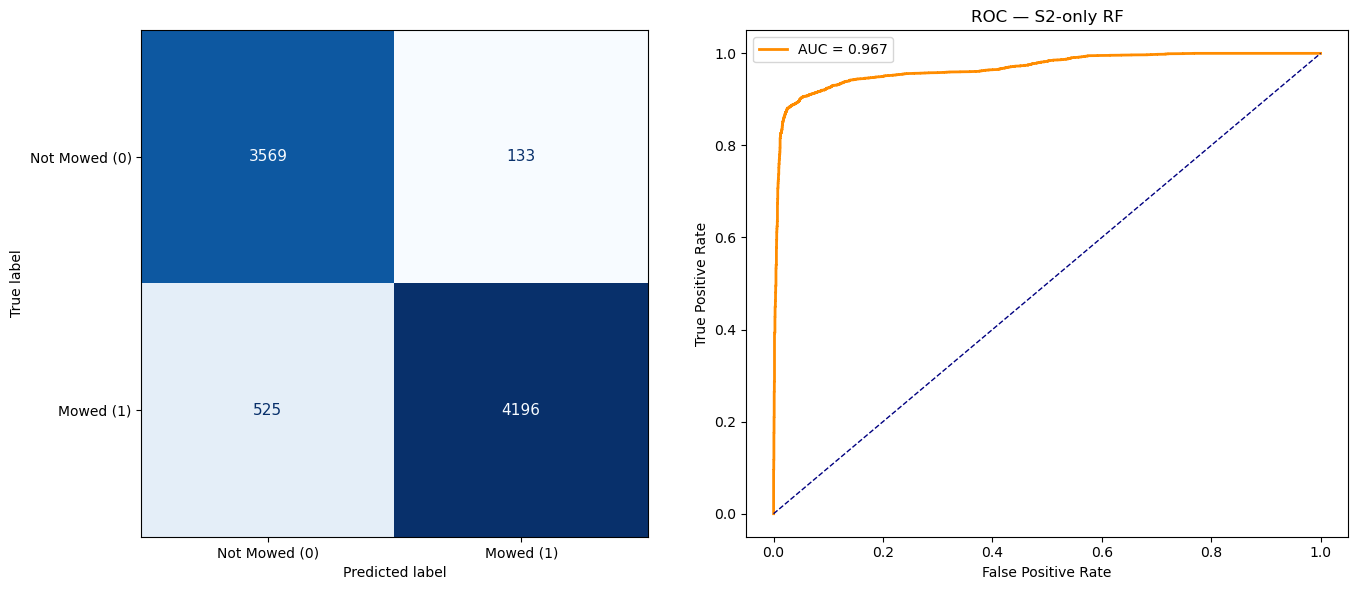

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2-only SVM ---
Accuracy: 92.83%
               precision    recall  f1-score   support

Not Mowed (0)       0.87      0.98      0.92      3702
    Mowed (1)       0.98      0.89      0.93      4721

     accuracy                           0.93      8423
    macro avg       0.93      0.93      0.93      8423
 weighted avg       0.93      0.93      0.93      8423



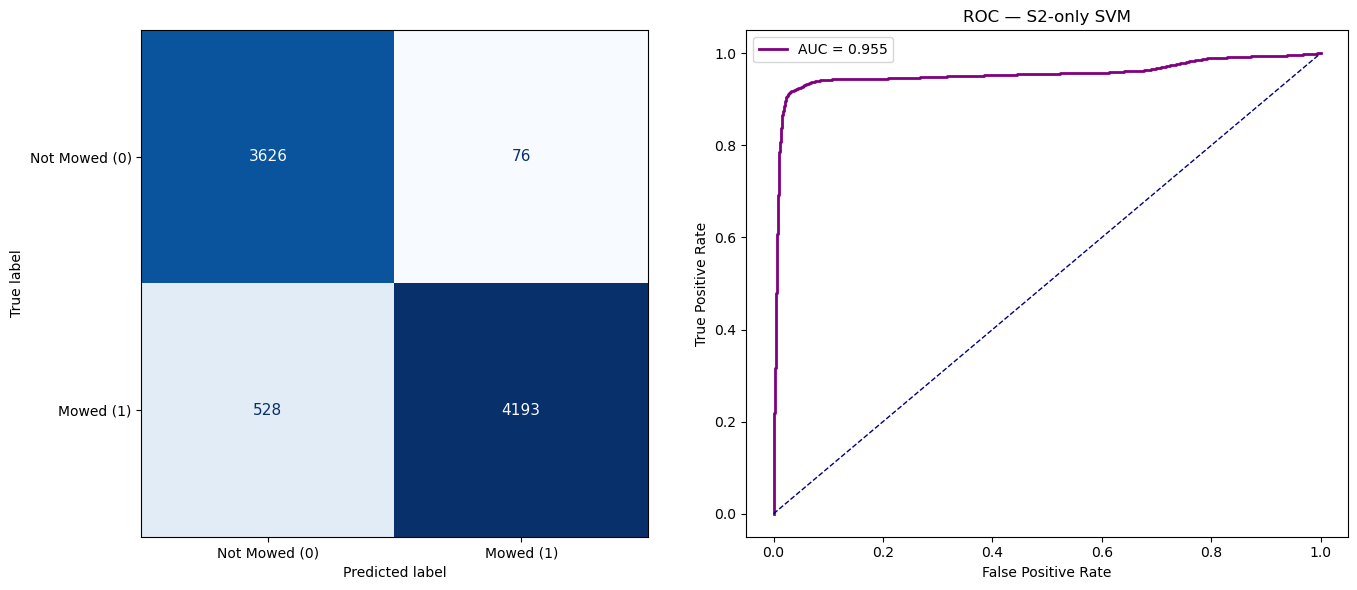

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2-only LGBM ---
Accuracy: 92.48%
               precision    recall  f1-score   support

Not Mowed (0)       0.87      0.97      0.92      3702
    Mowed (1)       0.97      0.89      0.93      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.93      8423



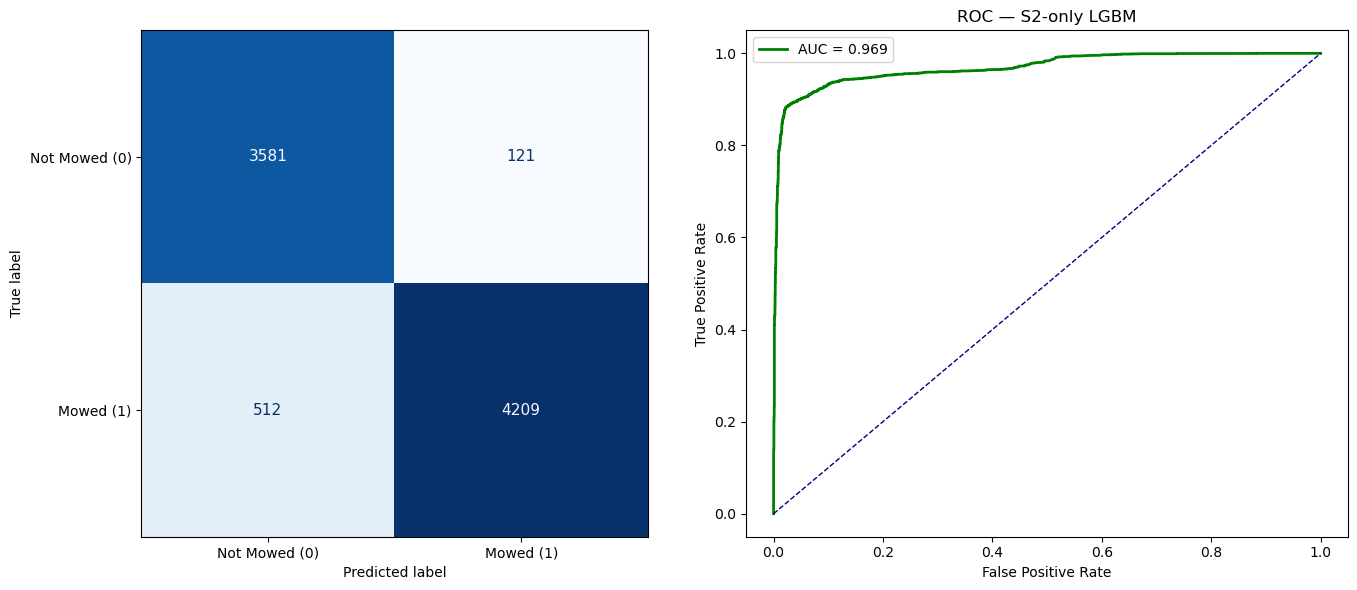

In [23]:
results_s2  = []
results_grd = []

X_train_s2 = X_train_s2_all
X_test_s2  = X_test_s2_all

print('=== Config 1: S2-only (5 lean features, ALL S2 events) ===')
model_s2_rf = train_tuned_rf(
    X_train_s2, y_train_s2, groups_train_s2, X_test_s2, y_test_s2,
    results_list=results_s2, model_alias='S2-only RF'
)
model_s2_svm = train_tuned_svm(
    X_train_s2, y_train_s2, groups_train_s2, X_test_s2, y_test_s2,
    results_list=results_s2, model_alias='S2-only SVM'
)
model_s2_lgbm = train_tuned_lgbm(
    X_train_s2, y_train_s2, groups_train_s2, X_test_s2, y_test_s2,
    results_list=results_s2, model_alias='S2-only LGBM'
)

---
## 4. Config 2: S1-Only (6 SAR features)

=== Config 2: S1-only (6 SAR features, GRD-eligible events) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S1-only RF ---
Accuracy: 53.73%
               precision    recall  f1-score   support

Not Mowed (0)       0.47      0.37      0.42      3702
    Mowed (1)       0.58      0.67      0.62      4721

     accuracy                           0.54      8423
    macro avg       0.52      0.52      0.52      8423
 weighted avg       0.53      0.54      0.53      8423



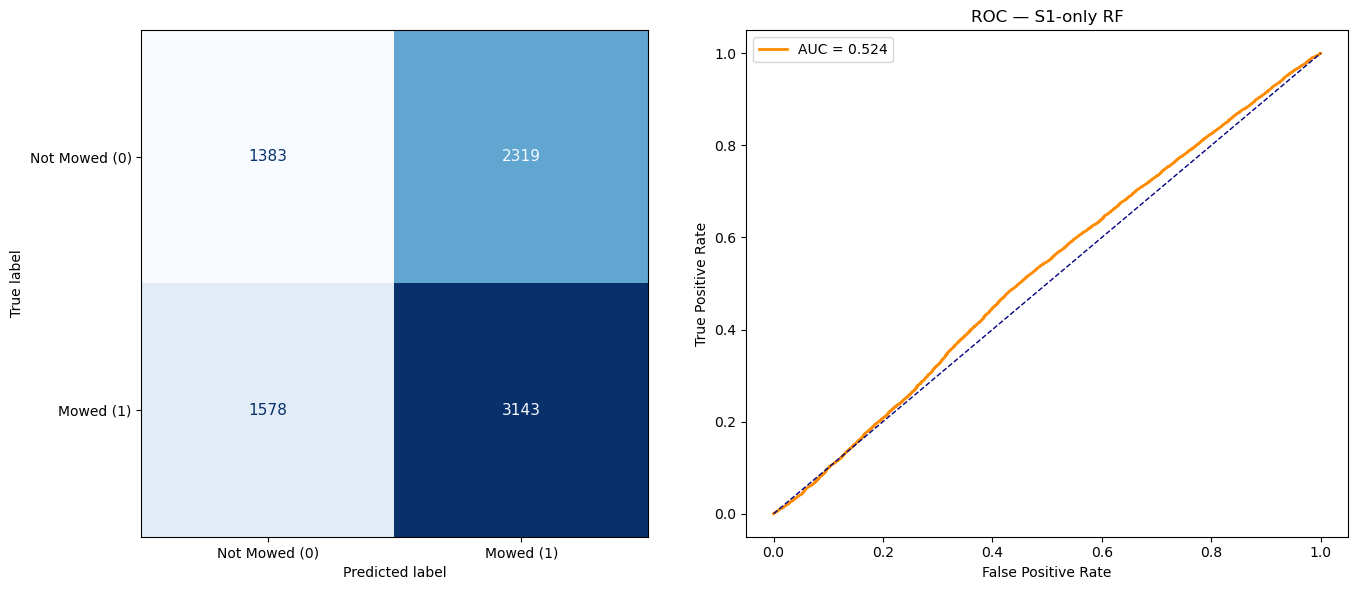

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S1-only SVM ---
Accuracy: 55.46%
               precision    recall  f1-score   support

Not Mowed (0)       0.48      0.13      0.20      3702
    Mowed (1)       0.57      0.89      0.69      4721

     accuracy                           0.55      8423
    macro avg       0.52      0.51      0.45      8423
 weighted avg       0.53      0.55      0.48      8423



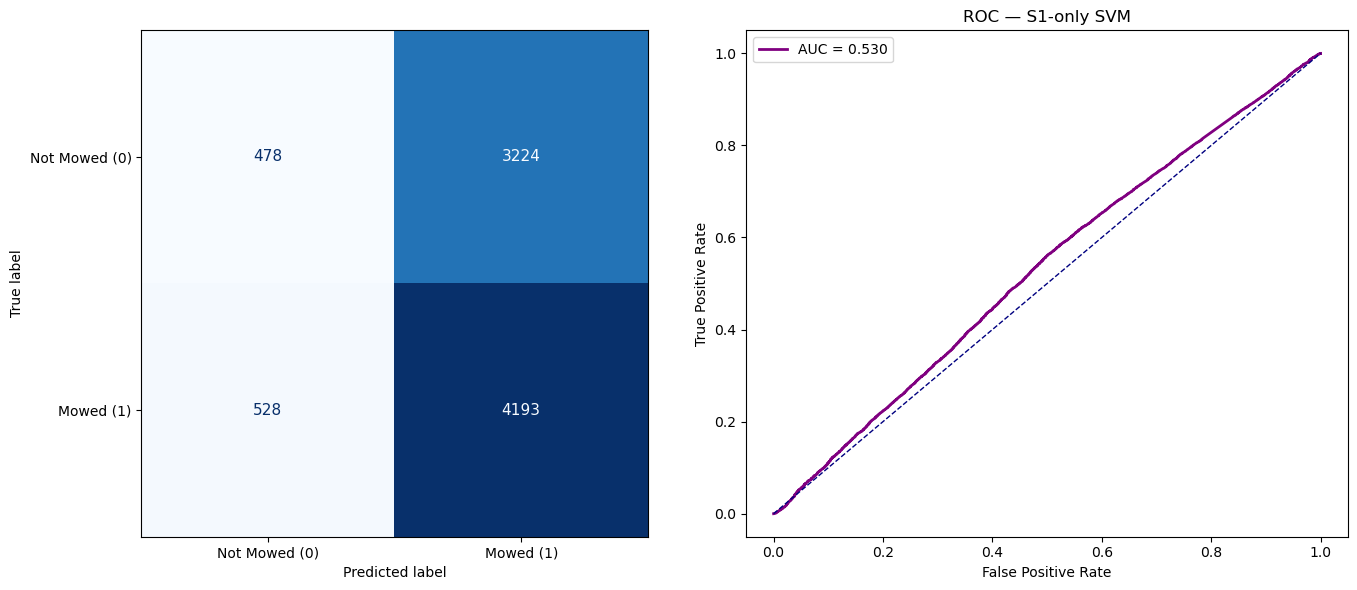

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S1-only LGBM ---
Accuracy: 54.09%
               precision    recall  f1-score   support

Not Mowed (0)       0.47      0.31      0.37      3702
    Mowed (1)       0.57      0.72      0.64      4721

     accuracy                           0.54      8423
    macro avg       0.52      0.52      0.51      8423
 weighted avg       0.53      0.54      0.52      8423



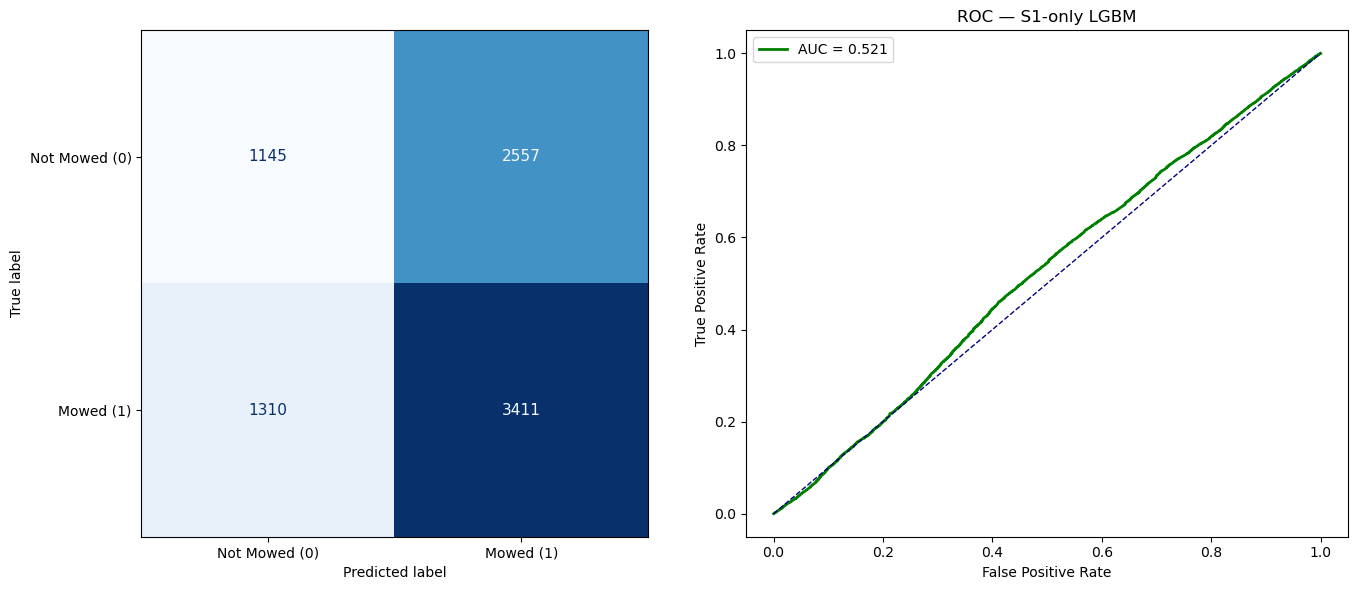

In [24]:
X_train_s1 = X_train_grd_all[SAR_FEATURES]
X_test_s1  = X_test_grd_all[SAR_FEATURES]

print('=== Config 2: S1-only (6 SAR features, GRD-eligible events) ===')
model_s1_rf = train_tuned_rf(
    X_train_s1, y_train_grd, groups_train_grd, X_test_s1, y_test_grd,
    results_list=results_grd, model_alias='S1-only RF'
)
model_s1_svm = train_tuned_svm(
    X_train_s1, y_train_grd, groups_train_grd, X_test_s1, y_test_grd,
    results_list=results_grd, model_alias='S1-only SVM'
)
model_s1_lgbm = train_tuned_lgbm(
    X_train_s1, y_train_grd, groups_train_grd, X_test_s1, y_test_grd,
    results_list=results_grd, model_alias='S1-only LGBM'
)

---
## 5. Config 3: S2+S1 Fusion (5 S2 lean + 6 SAR = 11 features)

=== Config 3: S2+S1 Fusion (11 features, GRD-eligible events) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 100}

--- S2+S1 Fusion RF ---
Accuracy: 92.06%
               precision    recall  f1-score   support

Not Mowed (0)       0.87      0.96      0.91      3702
    Mowed (1)       0.97      0.89      0.93      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



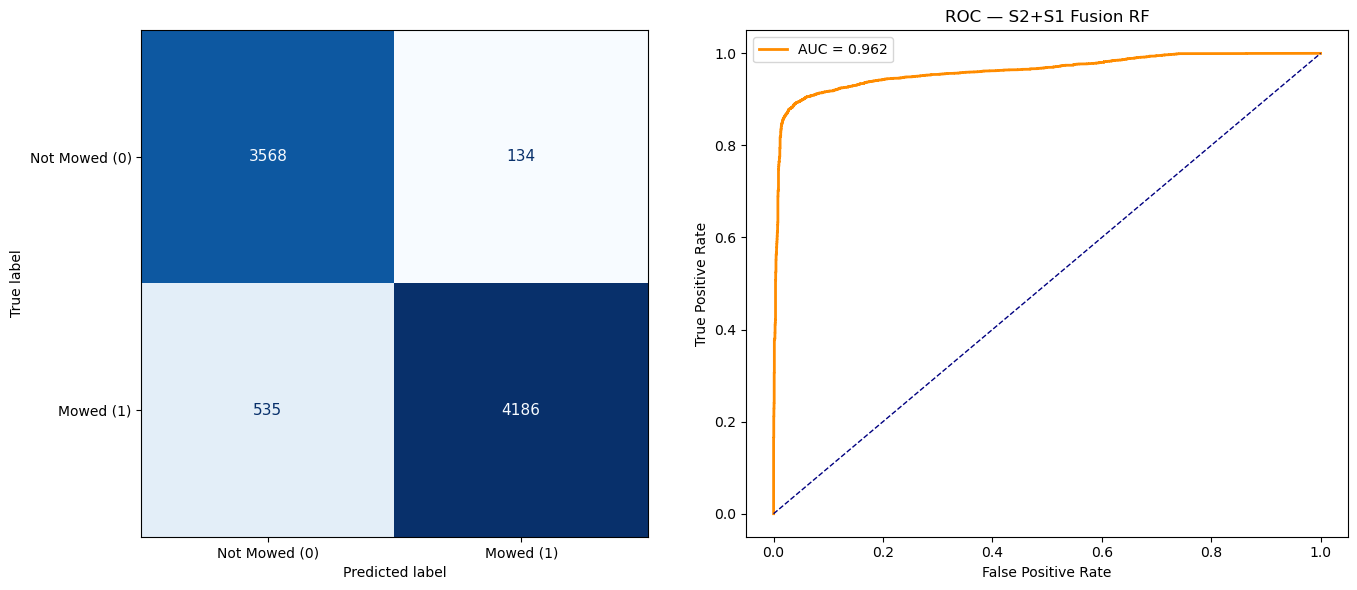

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2+S1 Fusion SVM ---
Accuracy: 90.74%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.96      0.90      3702
    Mowed (1)       0.96      0.87      0.91      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.91      0.91      8423
 weighted avg       0.91      0.91      0.91      8423



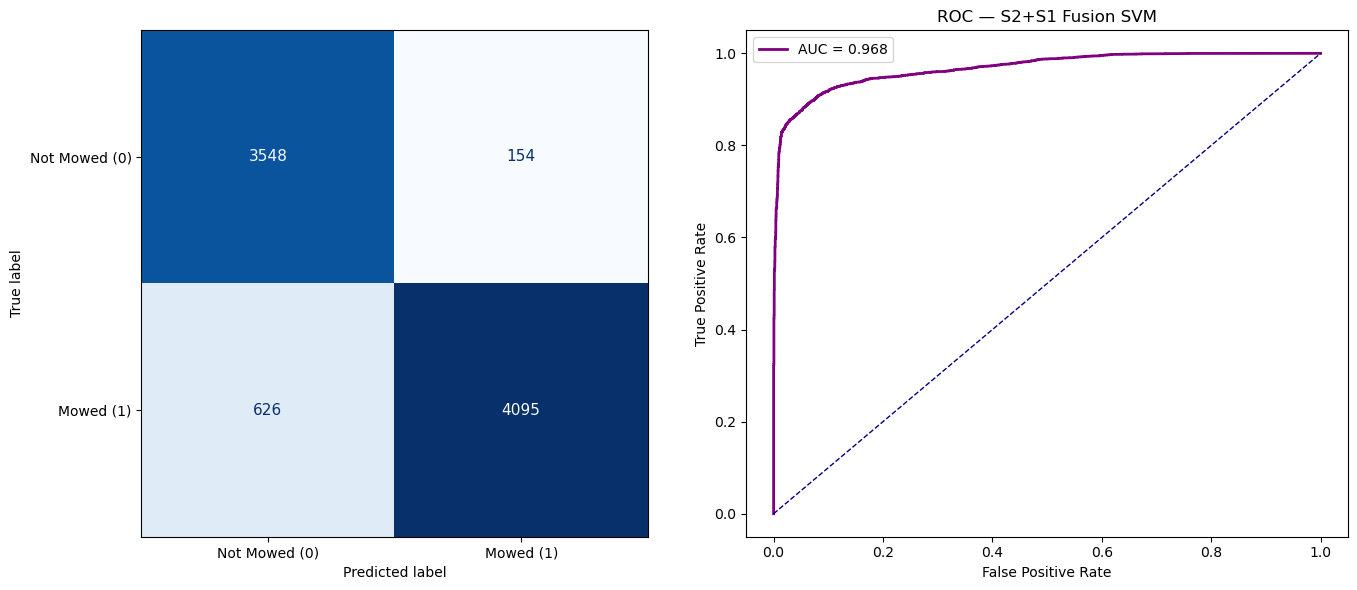

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 63}

--- S2+S1 Fusion LGBM ---
Accuracy: 90.82%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.95      0.90      3702
    Mowed (1)       0.96      0.88      0.91      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.91      0.91      8423
 weighted avg       0.91      0.91      0.91      8423



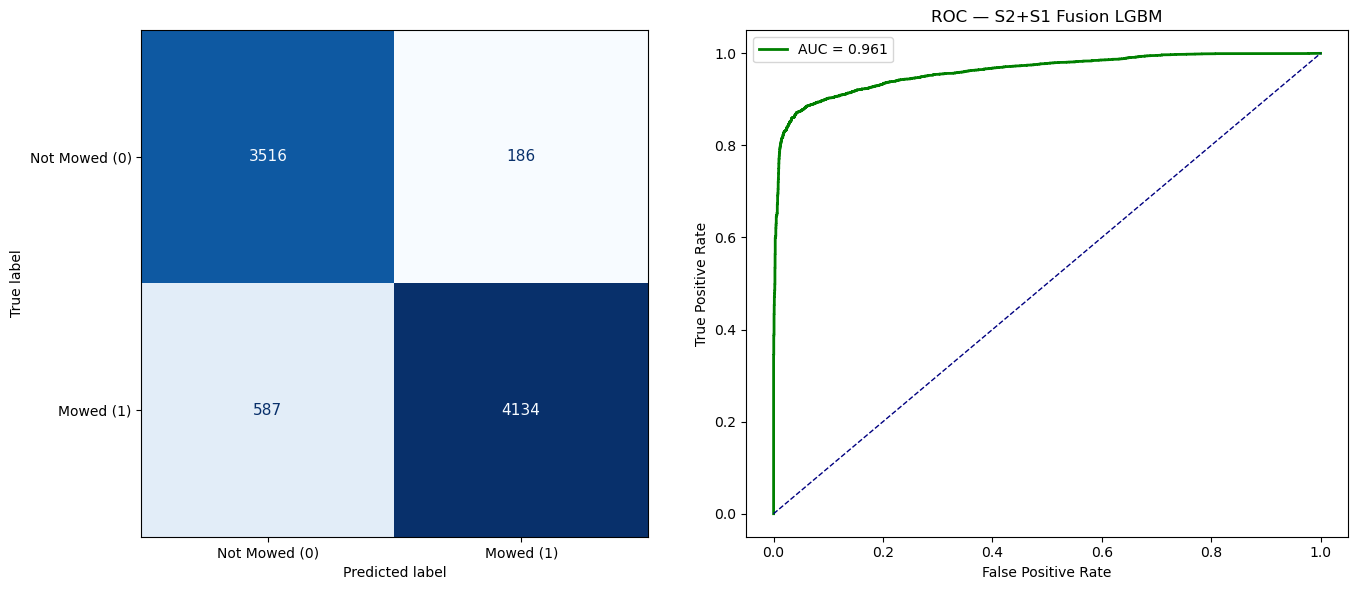

In [25]:
X_train_fusion = X_train_grd_all[S2_LEAN_FEATURES + SAR_FEATURES]
X_test_fusion  = X_test_grd_all[S2_LEAN_FEATURES + SAR_FEATURES]

print('=== Config 3: S2+S1 Fusion (11 features, GRD-eligible events) ===')
model_fusion_rf = train_tuned_rf(
    X_train_fusion, y_train_grd, groups_train_grd, X_test_fusion, y_test_grd,
    results_list=results_grd, model_alias='S2+S1 Fusion RF'
)
model_fusion_svm = train_tuned_svm(
    X_train_fusion, y_train_grd, groups_train_grd, X_test_fusion, y_test_grd,
    results_list=results_grd, model_alias='S2+S1 Fusion SVM'
)
model_fusion_lgbm = train_tuned_lgbm(
    X_train_fusion, y_train_grd, groups_train_grd, X_test_fusion, y_test_grd,
    results_list=results_grd, model_alias='S2+S1 Fusion LGBM'
)

---
## 6. Config 4: Hybrid Ablation (4 best S2 + 6 SAR = 10 features)

The PA2 best model (Hybrid SVM) used just 4 S2 features: `ndii_diff`, `ndii_after`,
`gndvi_diff`, `swir_after`. Adding the 6 SAR features to this lean set tests whether
SAR adds value on top of the most discriminative optical features.

=== Config 4: Hybrid+SAR ablation (10 features, GRD-eligible events) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- Hybrid+SAR RF ---
Accuracy: 91.63%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.97      0.91      3702
    Mowed (1)       0.97      0.88      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.92      0.92      8423
 weighted avg       0.92      0.92      0.92      8423



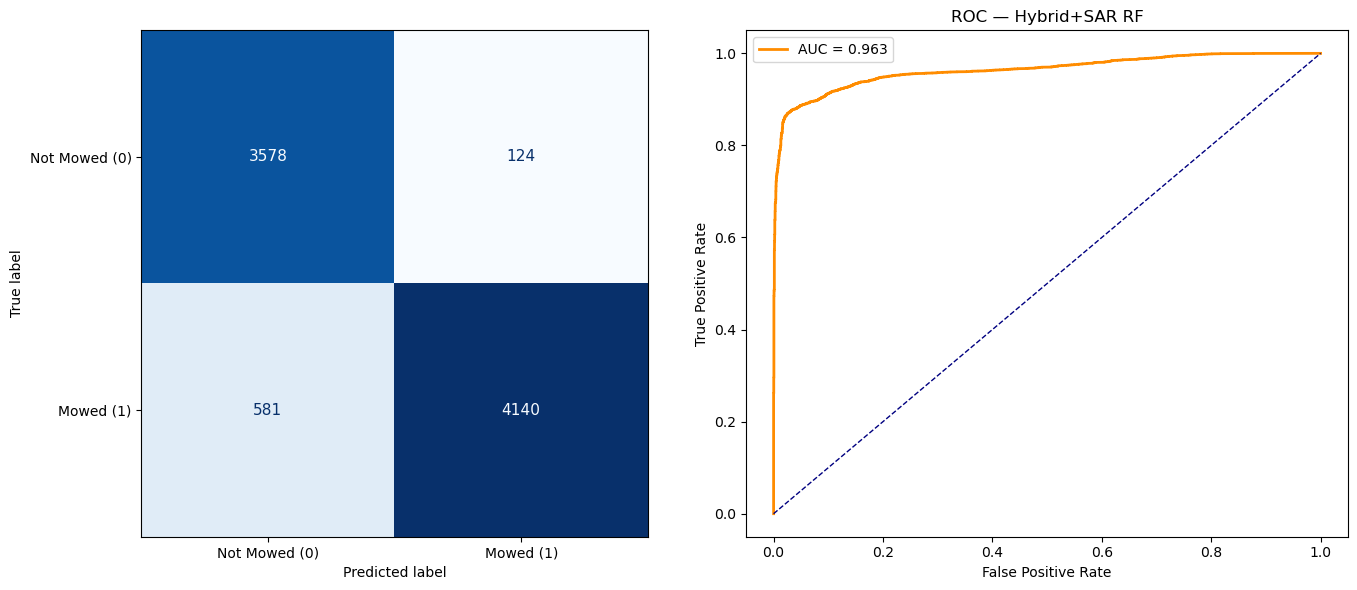

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- Hybrid+SAR SVM ---
Accuracy: 90.72%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.95      0.90      3702
    Mowed (1)       0.96      0.87      0.91      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.91      0.91      8423
 weighted avg       0.91      0.91      0.91      8423



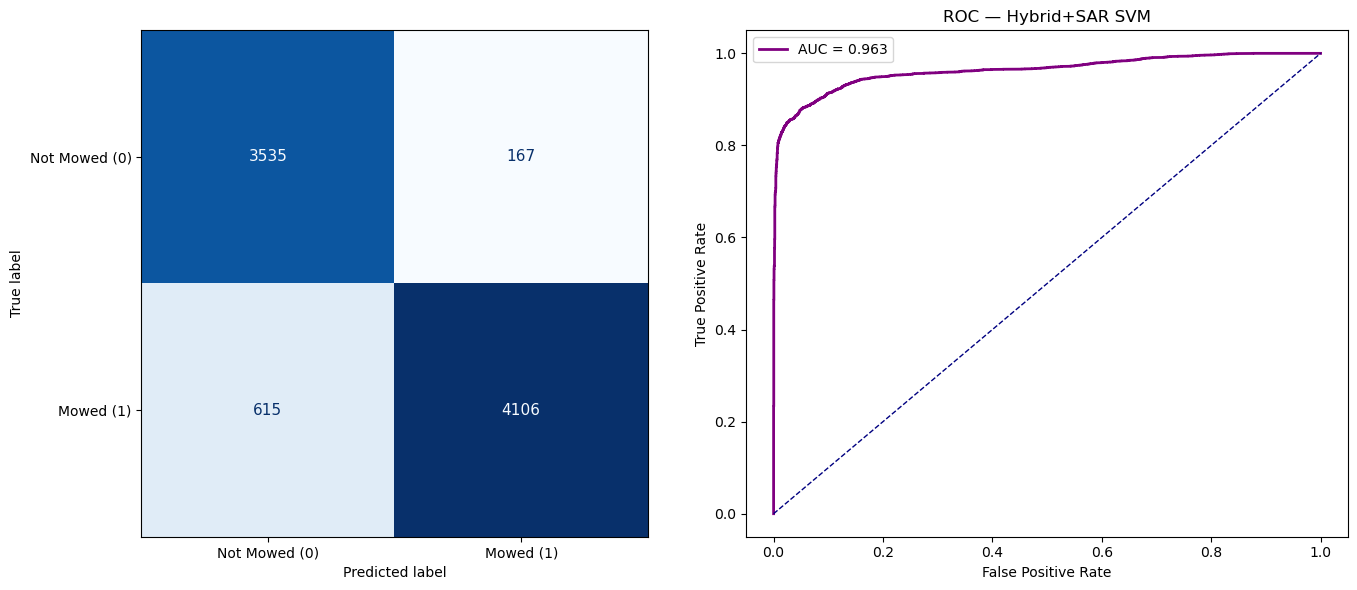

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- Hybrid+SAR LGBM ---
Accuracy: 90.41%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.94      0.90      3702
    Mowed (1)       0.95      0.87      0.91      4721

     accuracy                           0.90      8423
    macro avg       0.90      0.91      0.90      8423
 weighted avg       0.91      0.90      0.90      8423



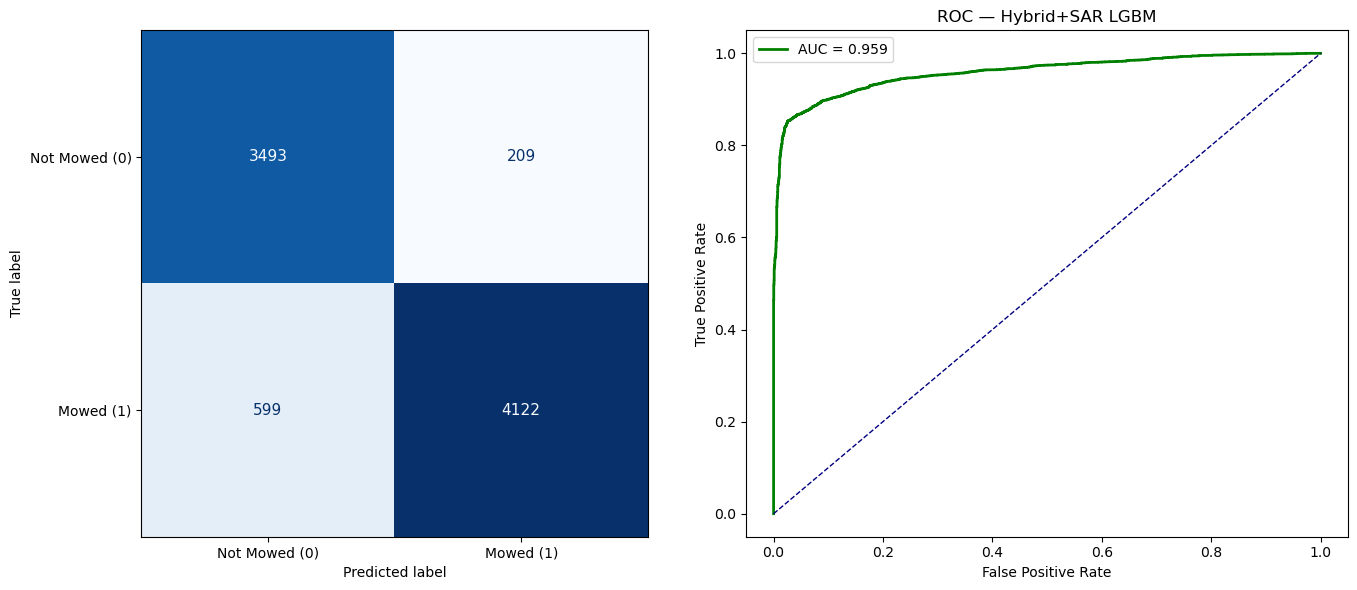

In [26]:
hybrid_sar_features = S2_HYBRID_FEATURES + SAR_FEATURES
X_train_hyb = X_train_grd_all[hybrid_sar_features]
X_test_hyb  = X_test_grd_all[hybrid_sar_features]

print('=== Config 4: Hybrid+SAR ablation (10 features, GRD-eligible events) ===')
model_hyb_rf = train_tuned_rf(
    X_train_hyb, y_train_grd, groups_train_grd, X_test_hyb, y_test_grd,
    results_list=results_grd, model_alias='Hybrid+SAR RF'
)
model_hyb_svm = train_tuned_svm(
    X_train_hyb, y_train_grd, groups_train_grd, X_test_hyb, y_test_grd,
    results_list=results_grd, model_alias='Hybrid+SAR SVM'
)
model_hyb_lgbm = train_tuned_lgbm(
    X_train_hyb, y_train_grd, groups_train_grd, X_test_hyb, y_test_grd,
    results_list=results_grd, model_alias='Hybrid+SAR LGBM'
)

---
## 5. Coherence Feature Configurations

All five coherence configs (5–9) train on the **coherence-eligible subset** (events where
all four coherence features are non-NaN after SNAP processing).
A separate GroupShuffleSplit is applied so results within this group are directly comparable.

Note: Configs 1–4 above use the full GRD-eligible event set; Configs 5–9 use the coherence
subset only. Compare within each group for fair ablation.

In [27]:
# === COHERENCE SECTION SETUP ===
# Load coherence-eligible subset and create a shared split for all coherence configs.
# Only events where all 4 coherence features are non-NaN are included.
# GroupShuffleSplit(group=match_id) prevents temporal data leakage.

coh_results = []

all_coh_features = S2_LEAN_FEATURES + SAR_FEATURES + COH_FEATURES   # 5+6+4 = 15 features
X_train_coh_all, y_train_coh, groups_train_coh, X_test_coh_all, y_test_coh = prepare_data(
    coh_df, all_coh_features, random_state=42
)

print(f'Coherence group — Train events: {groups_train_coh.nunique()}')
print(f'Coherence group — Test  events: {coh_df.loc[X_test_coh_all.index, "match_id"].nunique()}')

Training: 13556 samples (25 matches)
Testing:  3287 samples (7 matches)
Coherence group — Train events: 25
Coherence group — Test  events: 7


### Config 5: Coherence-Only (4 features)

Establishes the standalone value of InSAR coherence without any optical or backscatter input.
Analogue of Config 2 (S1-only) for the coherence modality.

=== Config 5: Coherence-only (4 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- Coh-only RF ---
Accuracy: 79.95%
               precision    recall  f1-score   support

Not Mowed (0)       0.83      0.77      0.80      1684
    Mowed (1)       0.77      0.83      0.80      1603

     accuracy                           0.80      3287
    macro avg       0.80      0.80      0.80      3287
 weighted avg       0.80      0.80      0.80      3287



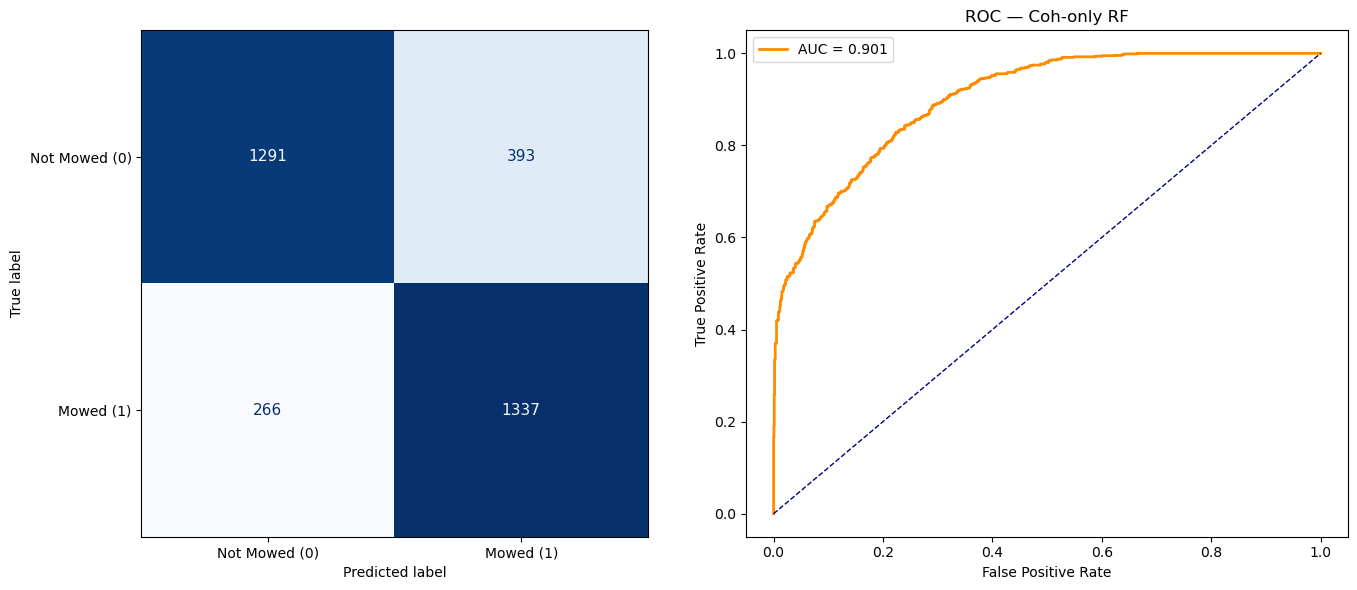

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- Coh-only SVM ---
Accuracy: 81.08%
               precision    recall  f1-score   support

Not Mowed (0)       0.84      0.78      0.81      1684
    Mowed (1)       0.79      0.84      0.81      1603

     accuracy                           0.81      3287
    macro avg       0.81      0.81      0.81      3287
 weighted avg       0.81      0.81      0.81      3287



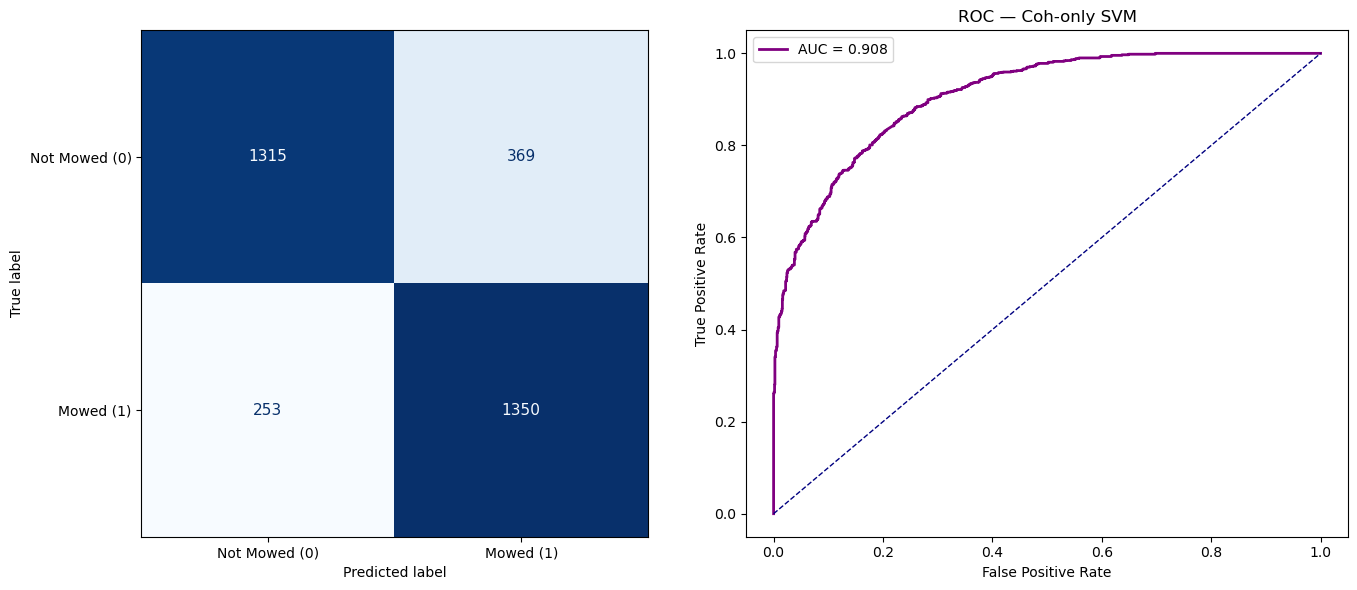

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.1, 'lgbm__num_leaves': 31}

--- Coh-only LGBM ---
Accuracy: 79.95%
               precision    recall  f1-score   support

Not Mowed (0)       0.83      0.77      0.80      1684
    Mowed (1)       0.78      0.83      0.80      1603

     accuracy                           0.80      3287
    macro avg       0.80      0.80      0.80      3287
 weighted avg       0.80      0.80      0.80      3287



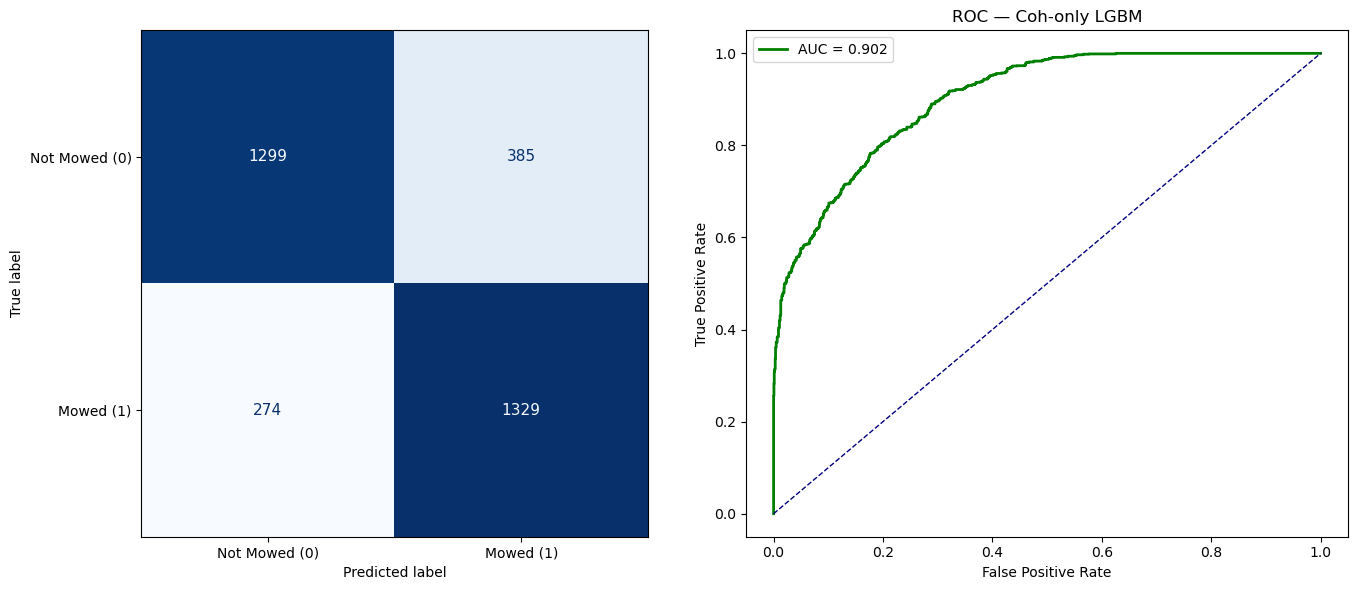

In [28]:
X_train_co = X_train_coh_all[COH_FEATURES]
X_test_co  = X_test_coh_all[COH_FEATURES]

print('=== Config 5: Coherence-only (4 features) ===')
model_co_rf = train_tuned_rf(
    X_train_co, y_train_coh, groups_train_coh, X_test_co, y_test_coh,
    results_list=coh_results, model_alias='Coh-only RF'
)
model_co_svm = train_tuned_svm(
    X_train_co, y_train_coh, groups_train_coh, X_test_co, y_test_coh,
    results_list=coh_results, model_alias='Coh-only SVM'
)
model_co_lgbm = train_tuned_lgbm(
    X_train_co, y_train_coh, groups_train_coh, X_test_co, y_test_coh,
    results_list=coh_results, model_alias='Coh-only LGBM'
)

### Config 6: SAR + Coherence (10 features)

Combines GRD backscatter (6) and coherence (4) — a pure SAR model with no optical input.
Tests whether coherence meaningfully improves over backscatter alone (Config 2).

=== Config 6: SAR+Coh (10 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 20, 'rf__n_estimators': 200}

--- SAR+Coh RF ---
Accuracy: 77.55%
               precision    recall  f1-score   support

Not Mowed (0)       0.80      0.76      0.78      1684
    Mowed (1)       0.76      0.80      0.78      1603

     accuracy                           0.78      3287
    macro avg       0.78      0.78      0.78      3287
 weighted avg       0.78      0.78      0.78      3287



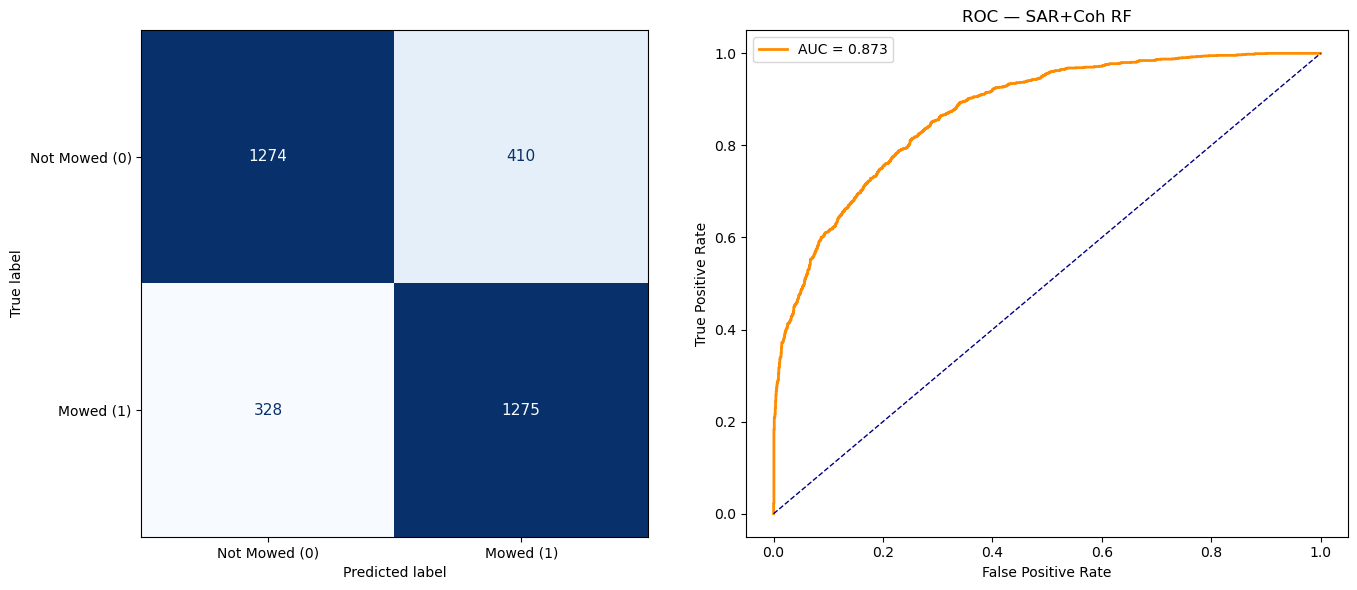

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- SAR+Coh SVM ---
Accuracy: 77.58%
               precision    recall  f1-score   support

Not Mowed (0)       0.79      0.76      0.78      1684
    Mowed (1)       0.76      0.79      0.77      1603

     accuracy                           0.78      3287
    macro avg       0.78      0.78      0.78      3287
 weighted avg       0.78      0.78      0.78      3287



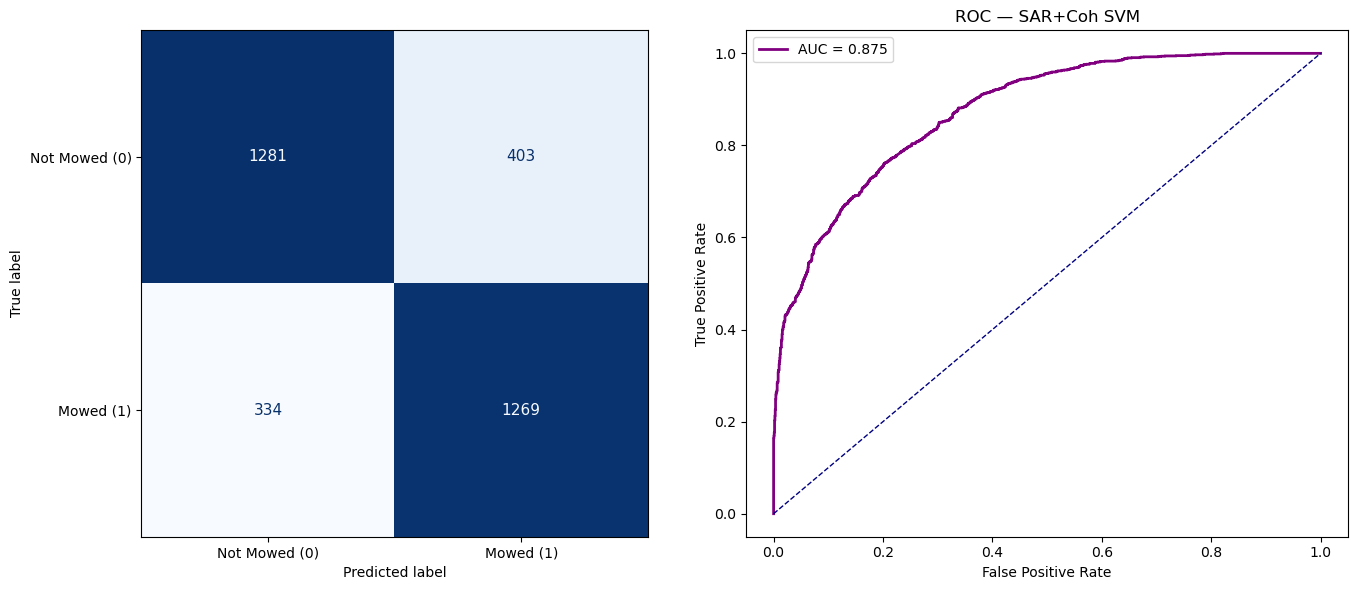

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- SAR+Coh LGBM ---
Accuracy: 78.98%
               precision    recall  f1-score   support

Not Mowed (0)       0.81      0.77      0.79      1684
    Mowed (1)       0.77      0.81      0.79      1603

     accuracy                           0.79      3287
    macro avg       0.79      0.79      0.79      3287
 weighted avg       0.79      0.79      0.79      3287



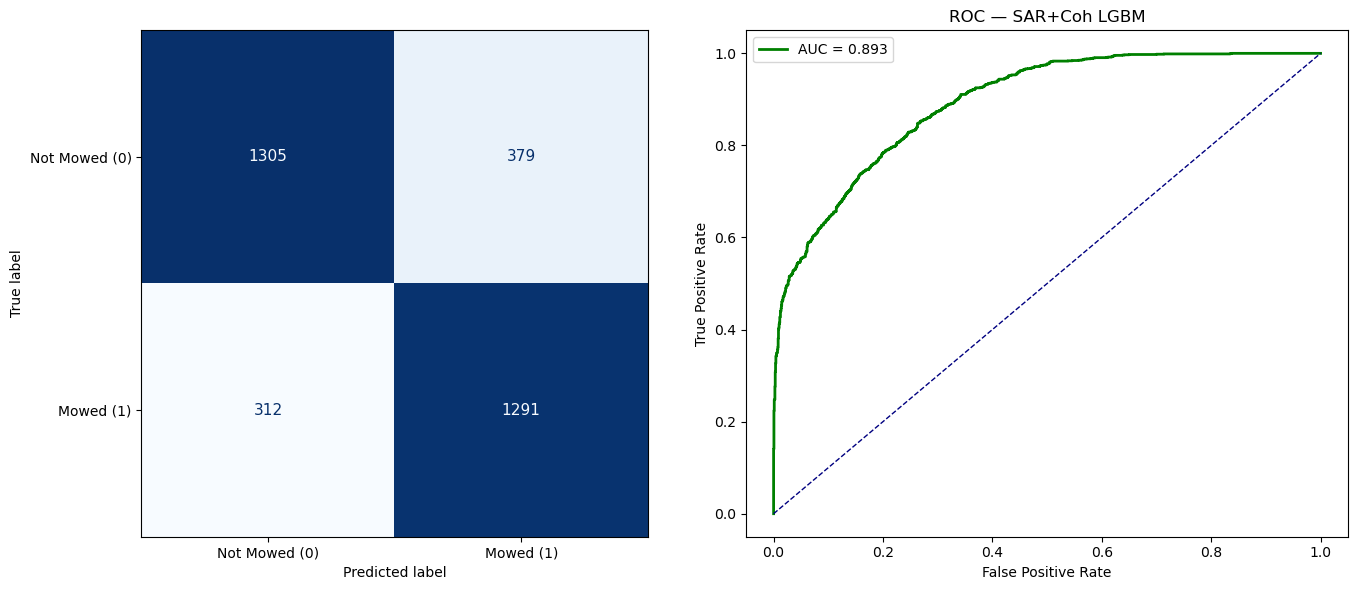

In [29]:
X_train_sc = X_train_coh_all[SAR_FEATURES + COH_FEATURES]
X_test_sc  = X_test_coh_all[SAR_FEATURES + COH_FEATURES]

print('=== Config 6: SAR+Coh (10 features) ===')
model_sc_rf = train_tuned_rf(
    X_train_sc, y_train_coh, groups_train_coh, X_test_sc, y_test_coh,
    results_list=coh_results, model_alias='SAR+Coh RF'
)
model_sc_svm = train_tuned_svm(
    X_train_sc, y_train_coh, groups_train_coh, X_test_sc, y_test_coh,
    results_list=coh_results, model_alias='SAR+Coh SVM'
)
model_sc_lgbm = train_tuned_lgbm(
    X_train_sc, y_train_coh, groups_train_coh, X_test_sc, y_test_coh,
    results_list=coh_results, model_alias='SAR+Coh LGBM'
)


### Config 7: S2 Lean + Coherence (5 S2 + 4 coh = 9 features)

Replaces GRD backscatter with coherence alongside optical features (using the lean S2 set).
Tests whether coherence is a better SAR complement to S2 than backscatter.

=== Config 7: S2+Coh (9 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 20, 'rf__n_estimators': 100}

--- S2+Coh RF ---
Accuracy: 93.43%
               precision    recall  f1-score   support

Not Mowed (0)       0.95      0.92      0.93      1684
    Mowed (1)       0.92      0.95      0.93      1603

     accuracy                           0.93      3287
    macro avg       0.93      0.93      0.93      3287
 weighted avg       0.93      0.93      0.93      3287



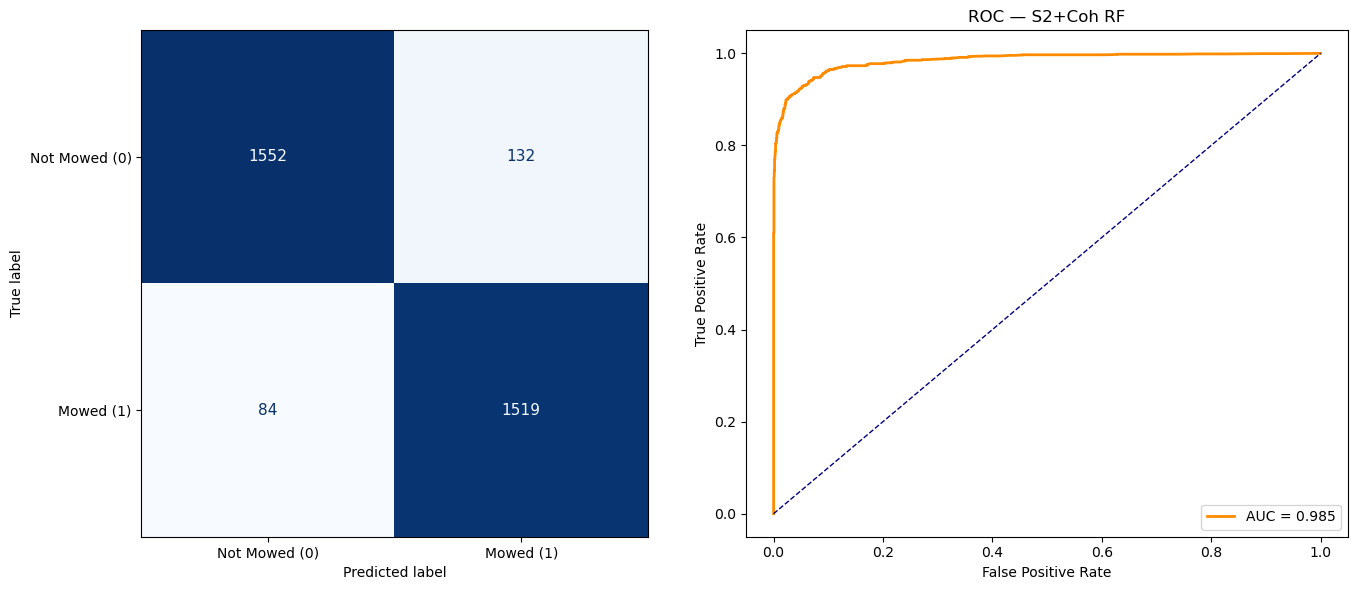

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale'}

--- S2+Coh SVM ---
Accuracy: 95.56%
               precision    recall  f1-score   support

Not Mowed (0)       0.96      0.95      0.96      1684
    Mowed (1)       0.95      0.96      0.95      1603

     accuracy                           0.96      3287
    macro avg       0.96      0.96      0.96      3287
 weighted avg       0.96      0.96      0.96      3287



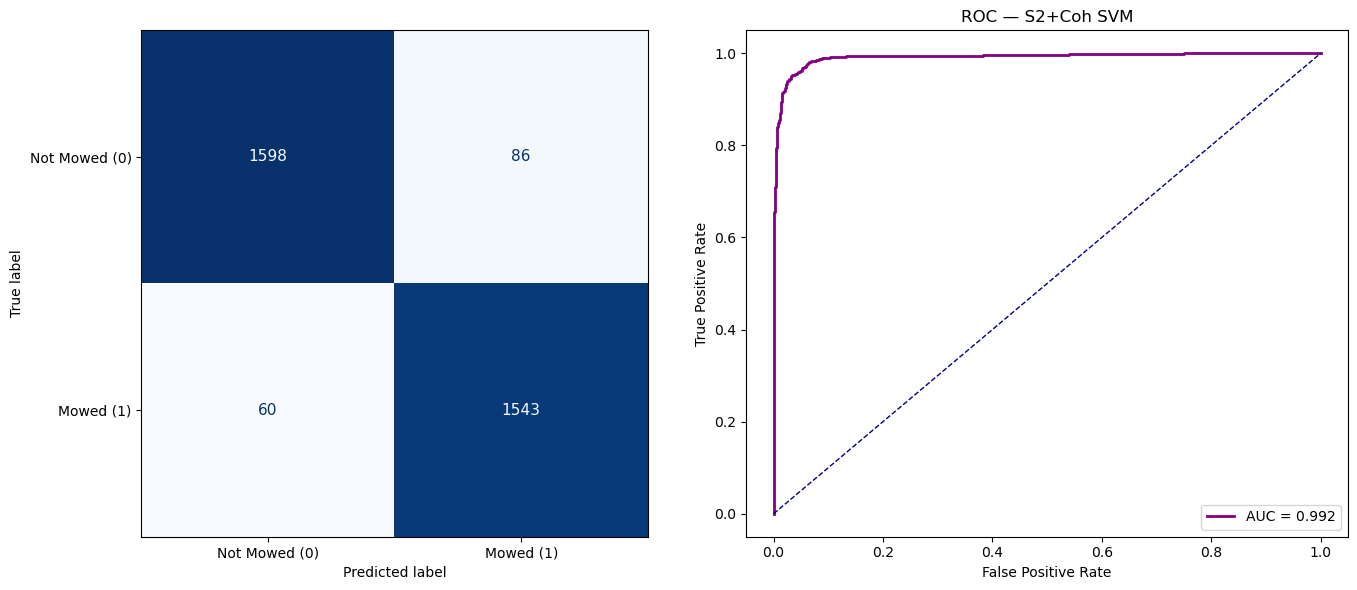

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.1, 'lgbm__num_leaves': 31}

--- S2+Coh LGBM ---
Accuracy: 95.50%
               precision    recall  f1-score   support

Not Mowed (0)       0.97      0.94      0.96      1684
    Mowed (1)       0.94      0.97      0.95      1603

     accuracy                           0.95      3287
    macro avg       0.96      0.96      0.95      3287
 weighted avg       0.96      0.95      0.95      3287



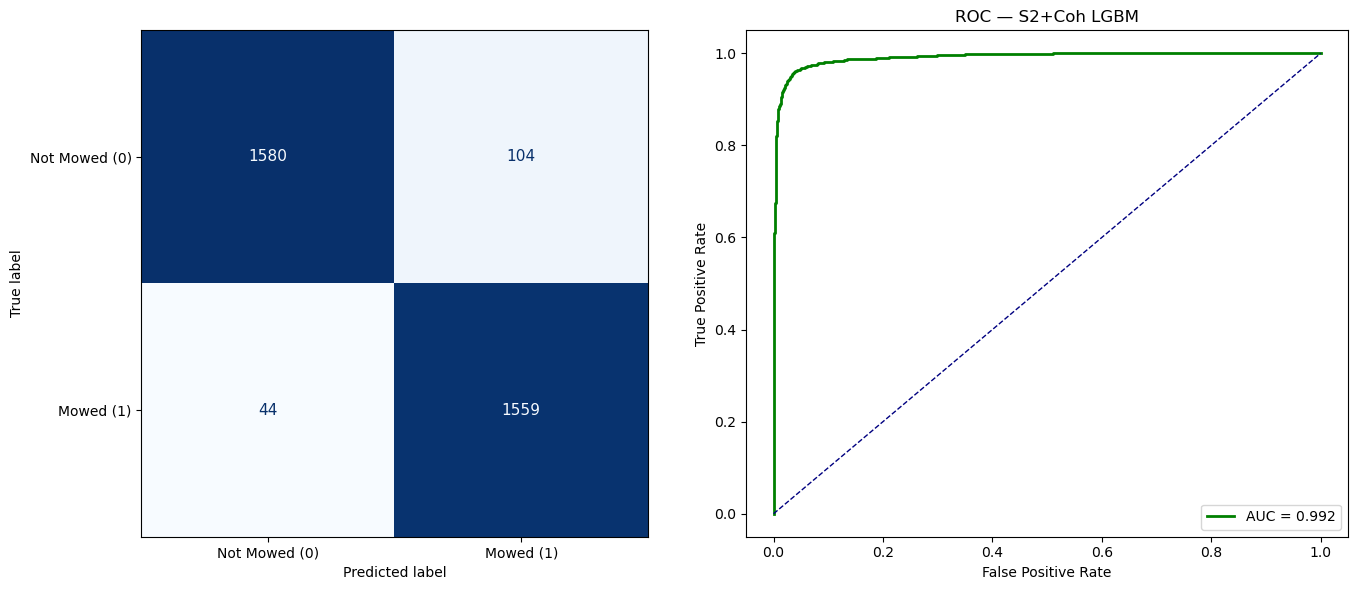

In [30]:
X_train_s2c = X_train_coh_all[S2_LEAN_FEATURES + COH_FEATURES]
X_test_s2c  = X_test_coh_all[S2_LEAN_FEATURES + COH_FEATURES]

print('=== Config 7: S2+Coh (9 features) ===')
model_s2c_rf = train_tuned_rf(
    X_train_s2c, y_train_coh, groups_train_coh, X_test_s2c, y_test_coh,
    results_list=coh_results, model_alias='S2+Coh RF'
)
model_s2c_svm = train_tuned_svm(
    X_train_s2c, y_train_coh, groups_train_coh, X_test_s2c, y_test_coh,
    results_list=coh_results, model_alias='S2+Coh SVM'
)
model_s2c_lgbm = train_tuned_lgbm(
    X_train_s2c, y_train_coh, groups_train_coh, X_test_s2c, y_test_coh,
    results_list=coh_results, model_alias='S2+Coh LGBM'
)

### Config 8: S2 Lean + SAR + Coherence — Full Fusion (5+6+4 = 15 features)

All available features using the lean S2 set. Establishes the performance ceiling when every modality is combined.

=== Config 8: S2+SAR+Coh full fusion (15 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 20, 'rf__n_estimators': 200}

--- S2+SAR+Coh RF ---
Accuracy: 95.31%
               precision    recall  f1-score   support

Not Mowed (0)       0.97      0.93      0.95      1684
    Mowed (1)       0.93      0.97      0.95      1603

     accuracy                           0.95      3287
    macro avg       0.95      0.95      0.95      3287
 weighted avg       0.95      0.95      0.95      3287



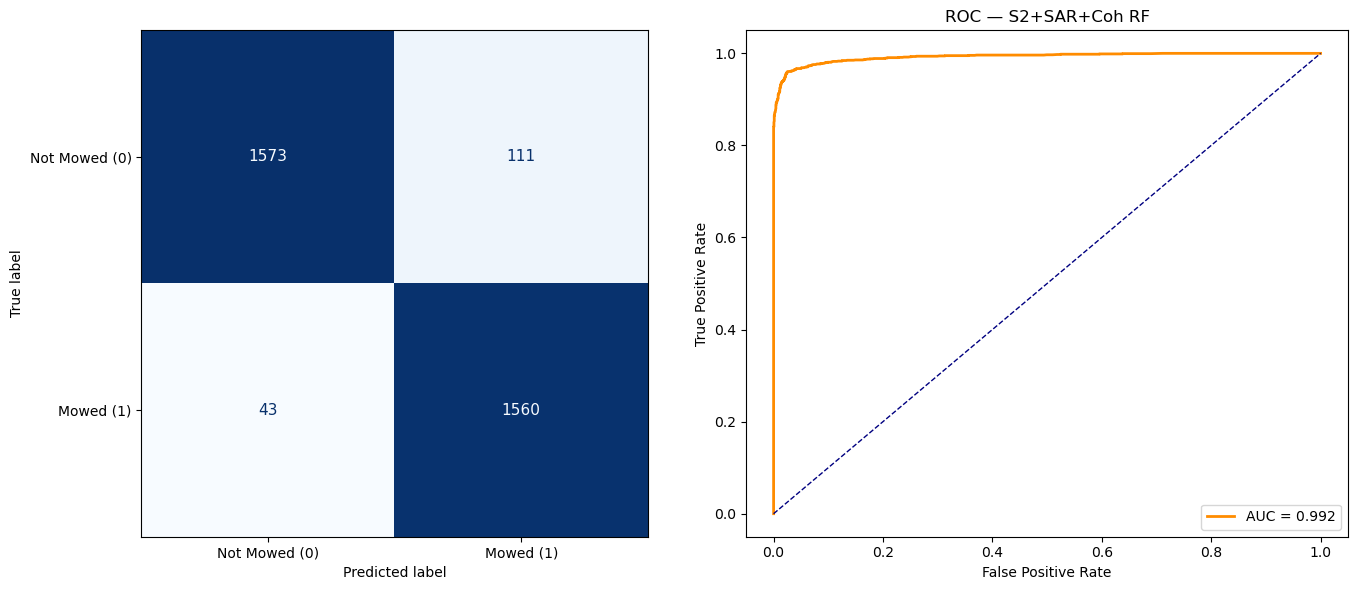

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- S2+SAR+Coh SVM ---
Accuracy: 95.07%
               precision    recall  f1-score   support

Not Mowed (0)       0.98      0.92      0.95      1684
    Mowed (1)       0.92      0.98      0.95      1603

     accuracy                           0.95      3287
    macro avg       0.95      0.95      0.95      3287
 weighted avg       0.95      0.95      0.95      3287



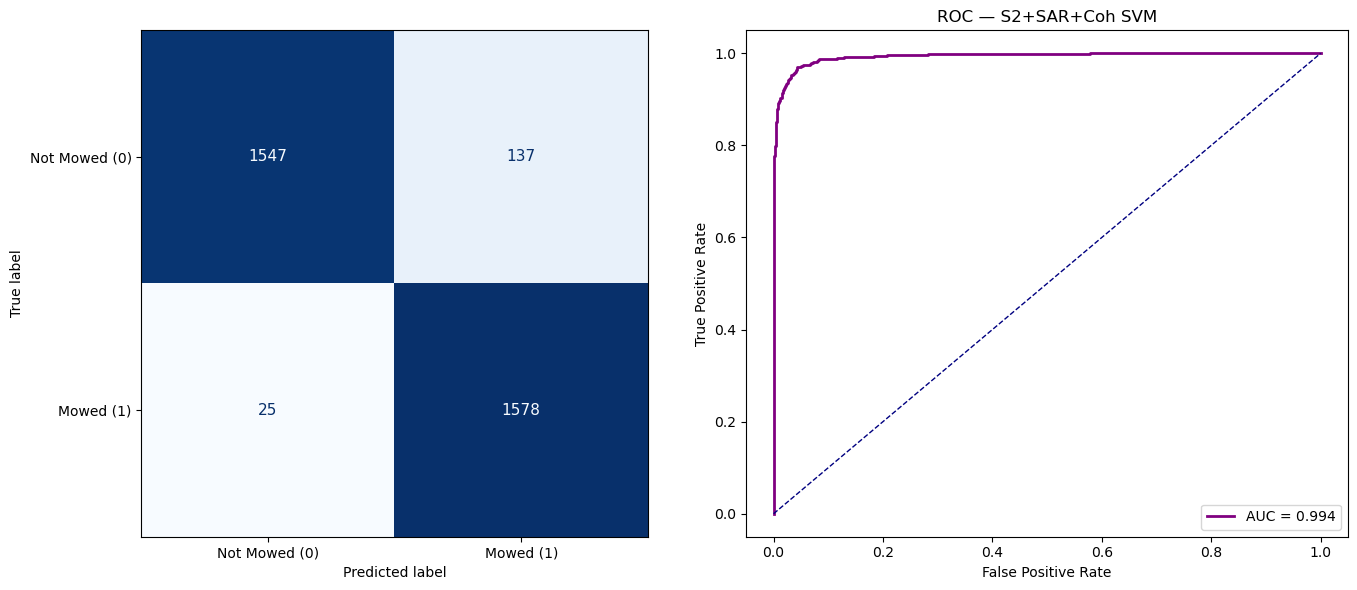

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.1, 'lgbm__num_leaves': 31}

--- S2+SAR+Coh LGBM ---
Accuracy: 95.62%
               precision    recall  f1-score   support

Not Mowed (0)       0.98      0.94      0.96      1684
    Mowed (1)       0.94      0.98      0.96      1603

     accuracy                           0.96      3287
    macro avg       0.96      0.96      0.96      3287
 weighted avg       0.96      0.96      0.96      3287



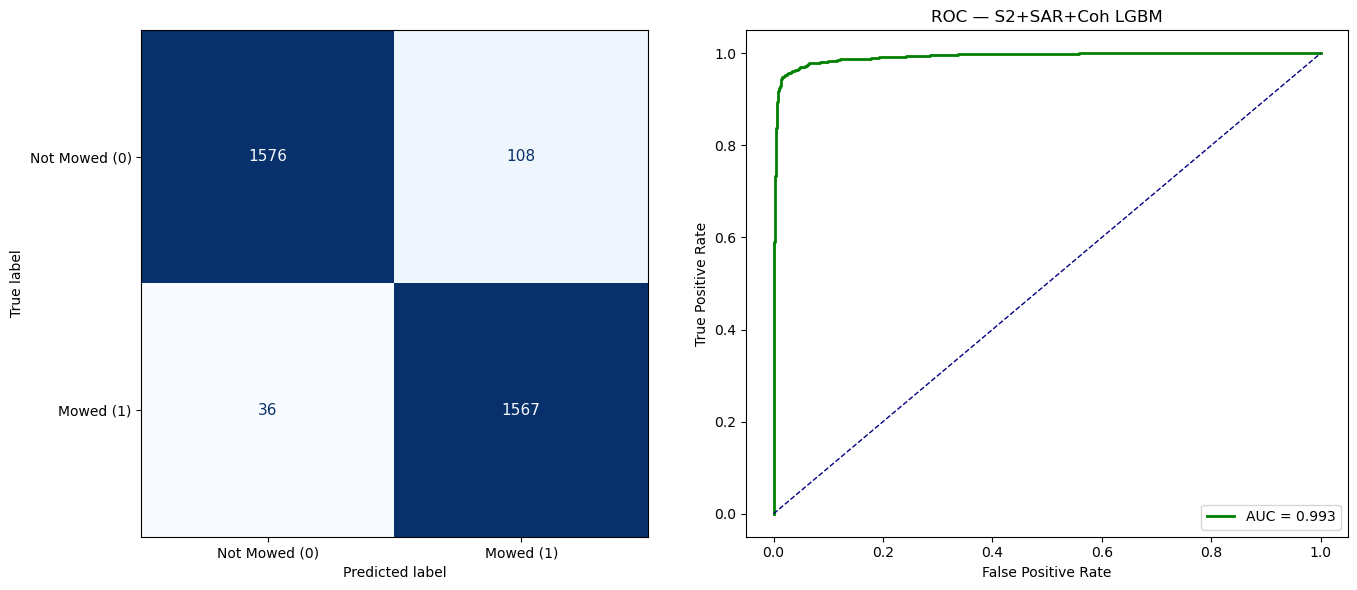

In [31]:
X_train_full = X_train_coh_all[all_coh_features]
X_test_full  = X_test_coh_all[all_coh_features]

print('=== Config 8: S2+SAR+Coh full fusion (15 features) ===')
model_full_rf = train_tuned_rf(
    X_train_full, y_train_coh, groups_train_coh, X_test_full, y_test_coh,
    results_list=coh_results, model_alias='S2+SAR+Coh RF'
)
model_full_svm = train_tuned_svm(
    X_train_full, y_train_coh, groups_train_coh, X_test_full, y_test_coh,
    results_list=coh_results, model_alias='S2+SAR+Coh SVM'
)
model_full_lgbm = train_tuned_lgbm(
    X_train_full, y_train_coh, groups_train_coh, X_test_full, y_test_coh,
    results_list=coh_results, model_alias='S2+SAR+Coh LGBM'
)

### Config 9: S2 Lean + Coherence Jumps (5 S2 + 2 coh = 7 features)

Thesis main result config. Uses only the two coherence jump features (`coh_vv_jump`, `coh_vh_jump`)
that had positive permutation importance. Absolute coherence values (`coh_vv`, `coh_vh`) are dropped
since they reflect landscape type rather than mowing events.
Directly comparable to Config 7 (S2+all coh) to quantify the cost of dropping `coh_vv`/`coh_vh`.

=== Config 9: S2+Coh Jumps (7 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 100}

--- S2+CohJumps RF ---
Accuracy: 92.91%
               precision    recall  f1-score   support

Not Mowed (0)       0.96      0.90      0.93      1684
    Mowed (1)       0.90      0.96      0.93      1603

     accuracy                           0.93      3287
    macro avg       0.93      0.93      0.93      3287
 weighted avg       0.93      0.93      0.93      3287



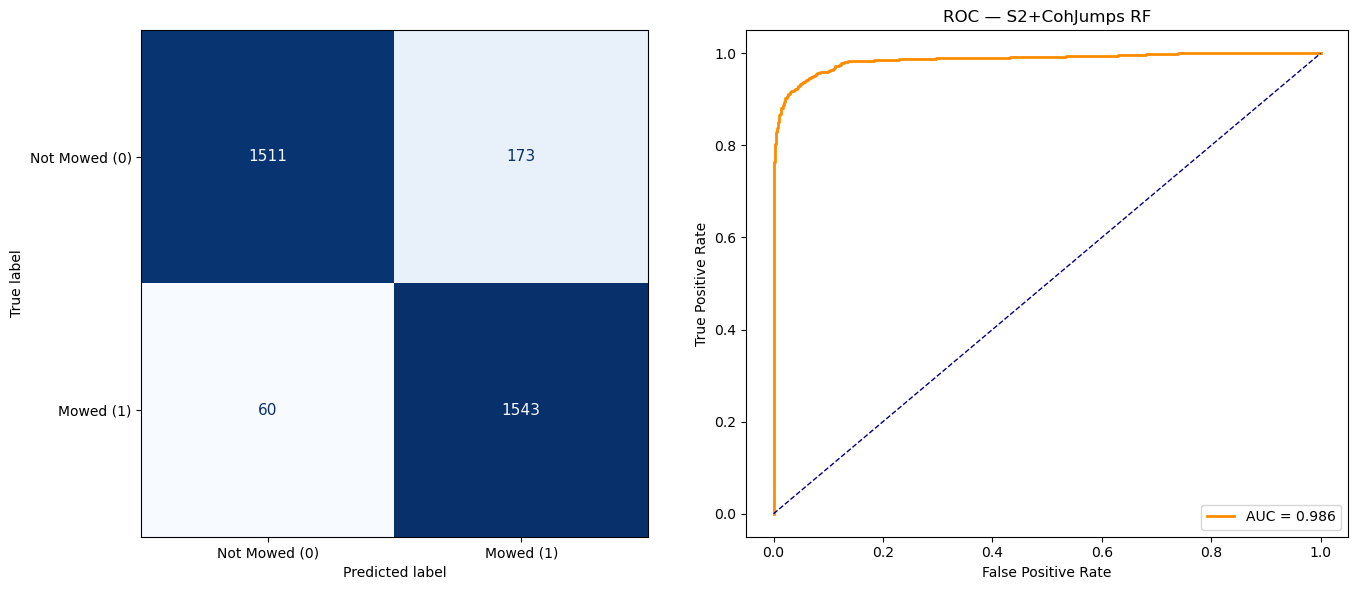

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- S2+CohJumps SVM ---
Accuracy: 95.95%
               precision    recall  f1-score   support

Not Mowed (0)       0.97      0.95      0.96      1684
    Mowed (1)       0.94      0.97      0.96      1603

     accuracy                           0.96      3287
    macro avg       0.96      0.96      0.96      3287
 weighted avg       0.96      0.96      0.96      3287



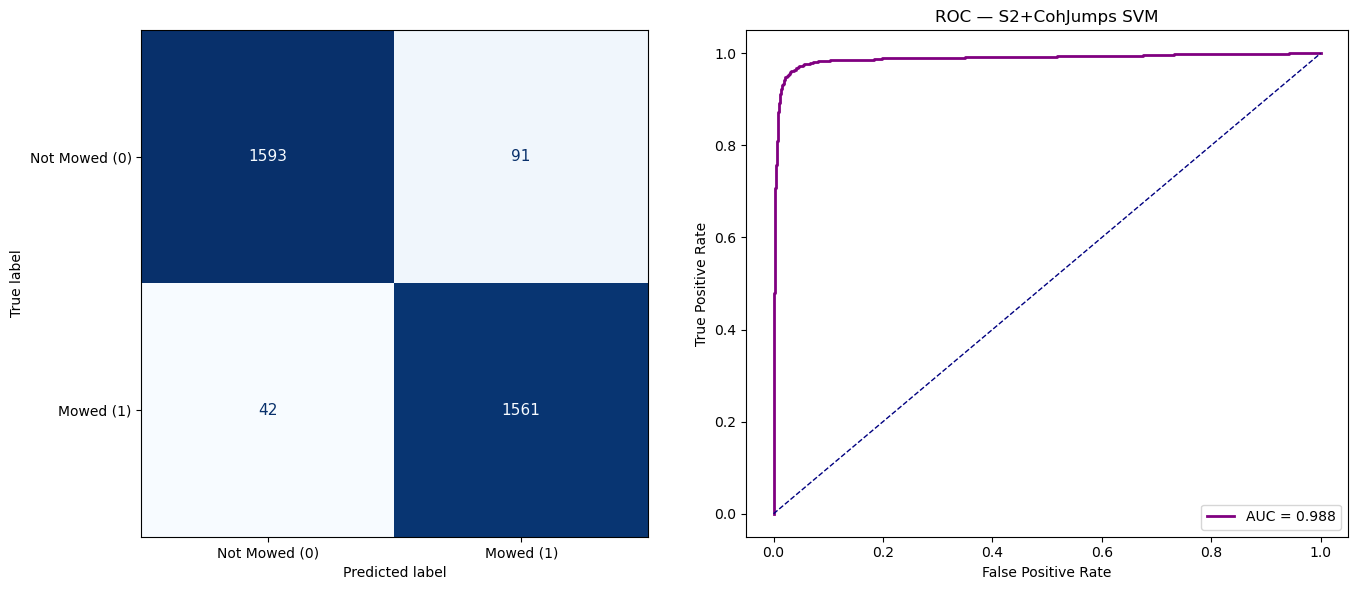

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2+CohJumps LGBM ---
Accuracy: 92.09%
               precision    recall  f1-score   support

Not Mowed (0)       0.96      0.88      0.92      1684
    Mowed (1)       0.89      0.96      0.92      1603

     accuracy                           0.92      3287
    macro avg       0.92      0.92      0.92      3287
 weighted avg       0.92      0.92      0.92      3287



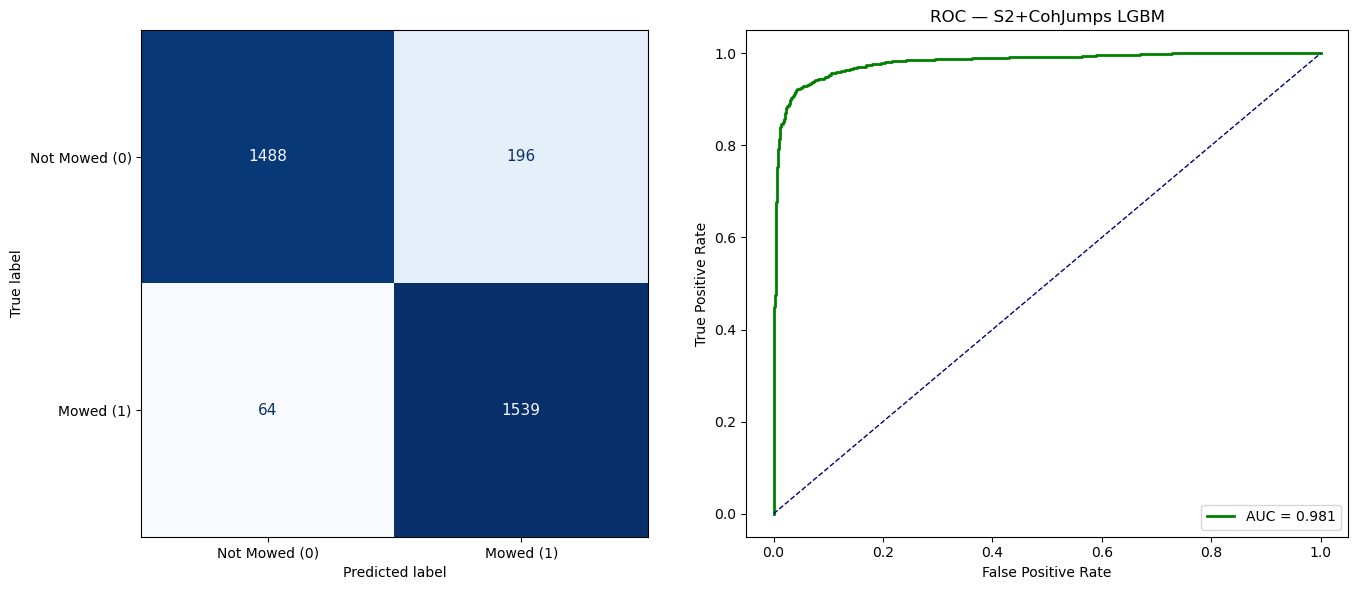

In [32]:
X_train_s2j = X_train_coh_all[S2_LEAN_FEATURES + COH_JUMP_FEATURES]
X_test_s2j  = X_test_coh_all[S2_LEAN_FEATURES + COH_JUMP_FEATURES]

print('=== Config 9: S2+Coh Jumps (7 features) ===')
model_s2j_rf = train_tuned_rf(
    X_train_s2j, y_train_coh, groups_train_coh, X_test_s2j, y_test_coh,
    results_list=coh_results, model_alias='S2+CohJumps RF'
)
model_s2j_svm = train_tuned_svm(
    X_train_s2j, y_train_coh, groups_train_coh, X_test_s2j, y_test_coh,
    results_list=coh_results, model_alias='S2+CohJumps SVM'
)
model_s2j_lgbm = train_tuned_lgbm(
    X_train_s2j, y_train_coh, groups_train_coh, X_test_s2j, y_test_coh,
    results_list=coh_results, model_alias='S2+CohJumps LGBM'
)

---
## Feature Importance & Redundancy Analysis

Three complementary views of which features drive prediction:

1. **MDI (Mean Decrease in Impurity)** — fast, from the already-trained RF models. Shows
   relative ranking within each feature set but can over-rate high-variance features.
2. **Permutation Importance** — shuffles each feature on the *test set* and measures F1 drop.
   More reliable than MDI and directly linked to generalisation performance. Error bars show
   variability across 20 random shuffles.
3. **Pearson Correlation Matrix** — shows linear redundancy between features and the label.
   Highly correlated pairs can be pruned without significant information loss.

Color coding: **blue** = S2 optical · **red** = SAR backscatter · **purple** = InSAR coherence

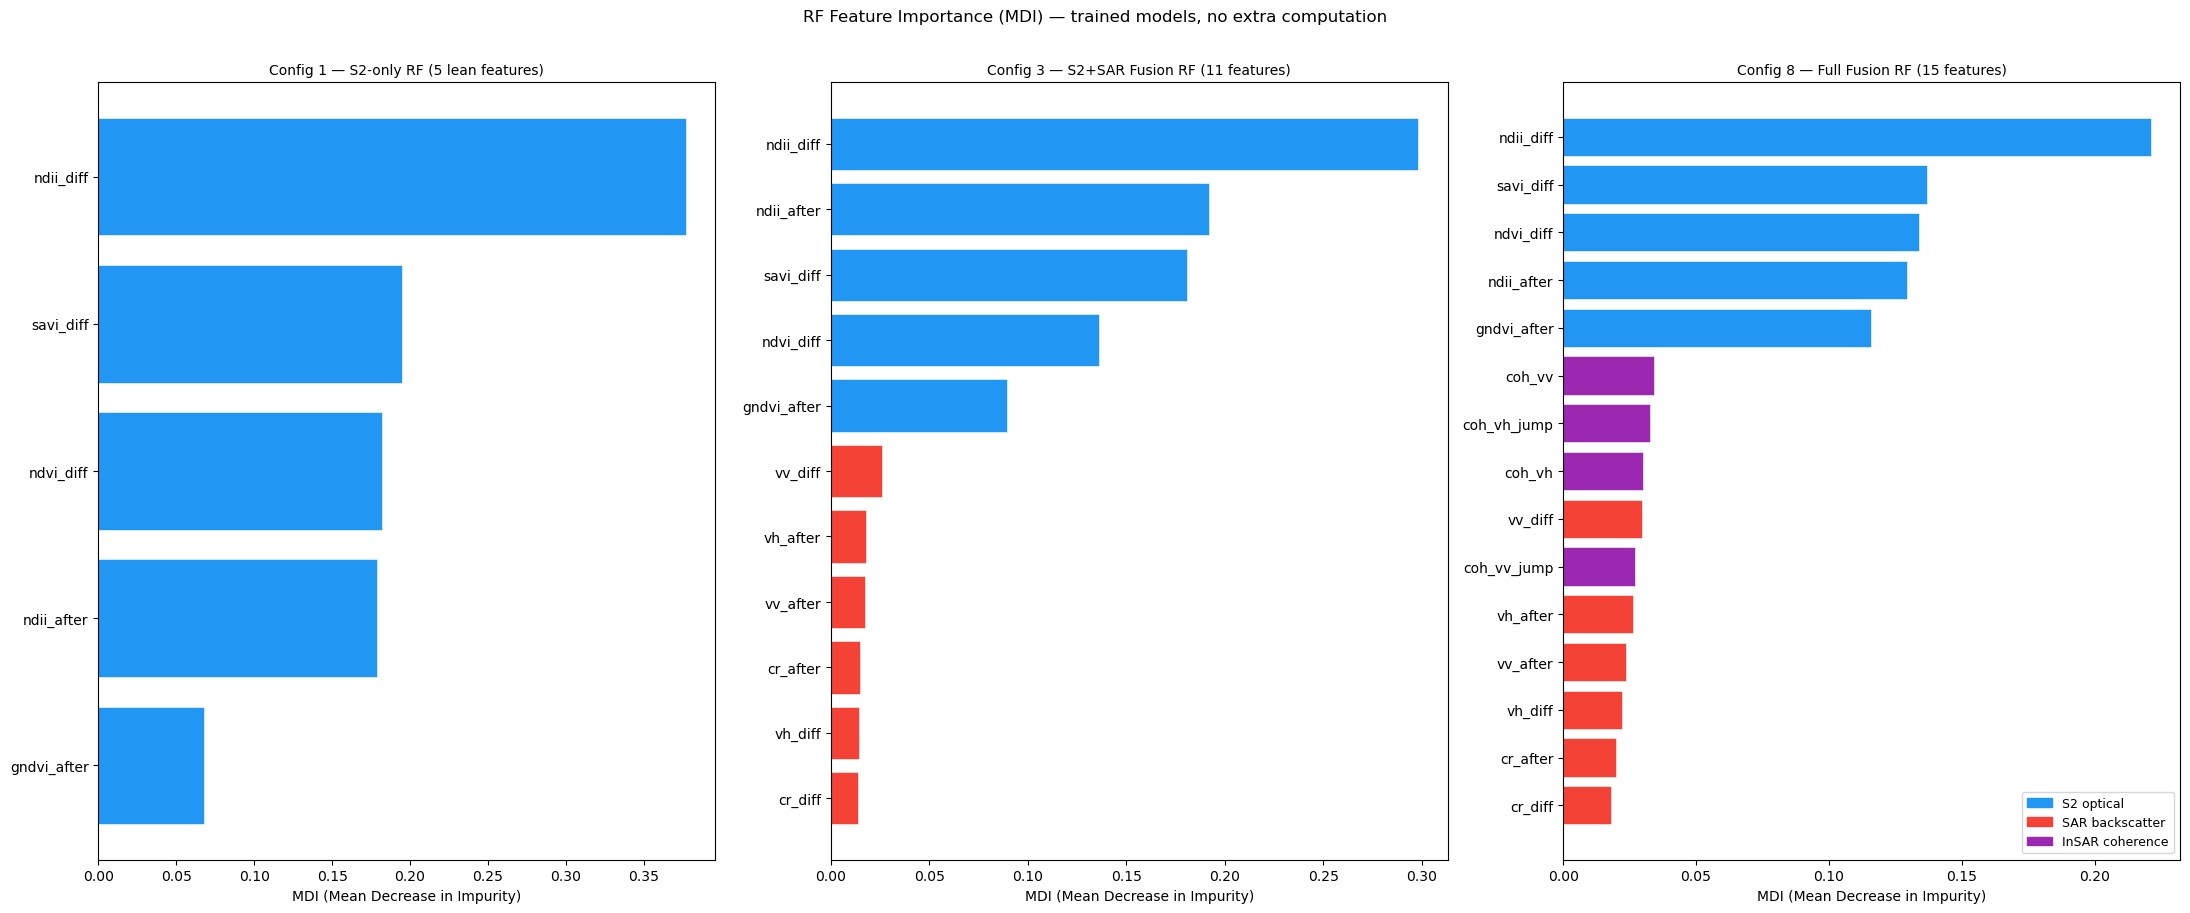

Saved: docs/images/feature_importance_mdi.png


In [14]:
import matplotlib.patches as mpatches

# Feature-to-colour mapping (by modality)
def feat_color(name):
    if name in COH_FEATURES: return '#9C27B0'  # purple = coherence
    if name in SAR_FEATURES:  return '#F44336'  # red = SAR
    return '#2196F3'                            # blue = S2

legend_elems = [
    mpatches.Patch(color='#2196F3', label='S2 optical'),
    mpatches.Patch(color='#F44336', label='SAR backscatter'),
    mpatches.Patch(color='#9C27B0', label='InSAR coherence'),
]

# Extract MDI from RF step inside the sklearn Pipeline
def rf_mdi(pipeline, feature_names):
    rf = pipeline.named_steps['rf']
    return pd.Series(rf.feature_importances_, index=feature_names)

mdi_s2     = rf_mdi(model_s2_rf,     S2_LEAN_FEATURES)
mdi_fusion = rf_mdi(model_fusion_rf, S2_LEAN_FEATURES + SAR_FEATURES)
mdi_full   = rf_mdi(model_full_rf,   all_coh_features)

fig, axes = plt.subplots(1, 3, figsize=(22, 9))

for ax, mdi, title in [
    (axes[0], mdi_s2,     'Config 1 — S2-only RF (5 lean features)'),
    (axes[1], mdi_fusion, 'Config 3 — S2+SAR Fusion RF (11 features)'),
    (axes[2], mdi_full,   'Config 8 — Full Fusion RF (15 features)'),
]:
    mdi_sorted = mdi.sort_values(ascending=True)
    colors = [feat_color(f) for f in mdi_sorted.index]
    ax.barh(mdi_sorted.index, mdi_sorted.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('MDI (Mean Decrease in Impurity)')
    ax.set_title(title, fontsize=10)
    ax.axvline(0, color='grey', lw=0.5)

axes[2].legend(handles=legend_elems, loc='lower right', fontsize=9)
plt.suptitle('RF Feature Importance (MDI) — trained models, no extra computation', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'feature_importance_mdi.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: docs/images/feature_importance_mdi.png')

Computing permutation importance on Full Fusion RF (n_repeats=20)...

Permutation Importance — Full Fusion RF (15 features, coh test set):
    Feature      Mean      Std
  ndii_diff  0.104218 0.003884
 ndii_after  0.055167 0.003050
gndvi_after  0.009203 0.002210
coh_vv_jump  0.008081 0.001437
coh_vh_jump  0.004245 0.001088
     coh_vv  0.003991 0.001385
     coh_vh  0.003691 0.001687
    cr_diff  0.001166 0.000875
   cr_after -0.000483 0.000890
  savi_diff -0.000862 0.002015
    vh_diff -0.000920 0.001372
   vh_after -0.001107 0.001465
   vv_after -0.004547 0.001085
  ndvi_diff -0.004804 0.001643
    vv_diff -0.006182 0.000862

Features with mean perm-importance > 0.005 (4 total):
  S2 (3/5):         ['ndii_diff', 'ndii_after', 'gndvi_after']
  SAR (0/6):        []
  Coherence (1/4):  ['coh_vv_jump']


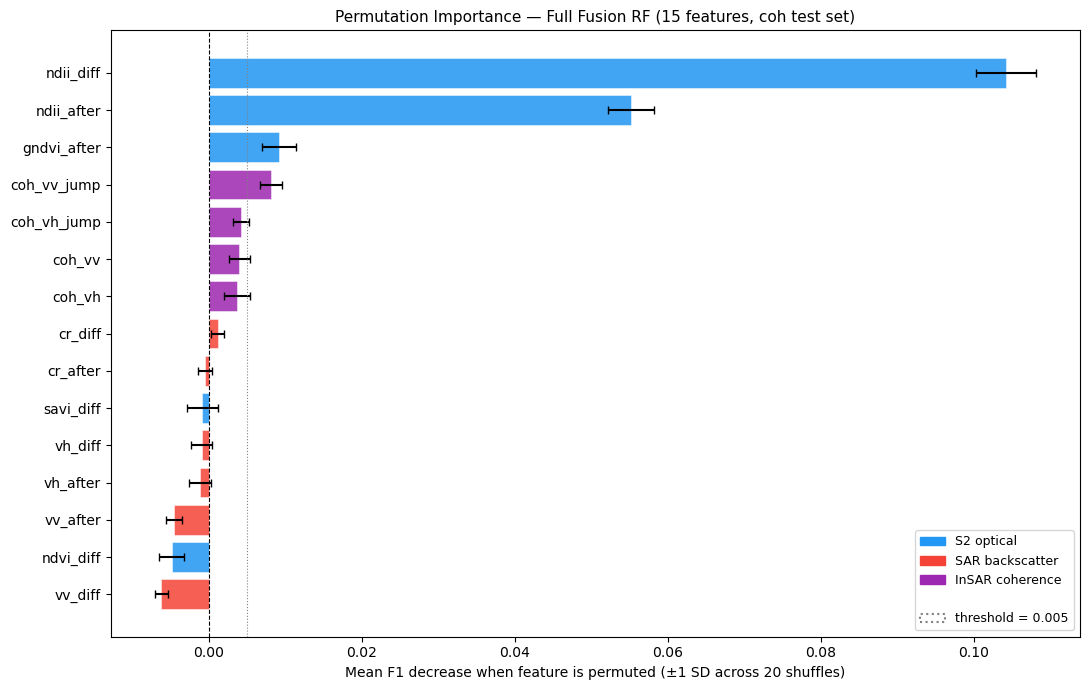

Saved: docs/images/feature_importance_permutation.png


In [15]:
from sklearn.inspection import permutation_importance

# Permutation importance on the full 15-feature RF, evaluated on the coh test set.
# n_repeats=20 gives stable error bars without excessive runtime (~1-2 min).
print('Computing permutation importance on Full Fusion RF (n_repeats=20)...')
perm_result = permutation_importance(
    model_full_rf,
    X_test_coh_all[all_coh_features],
    y_test_coh,
    n_repeats=20,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'Feature': all_coh_features,
    'Mean':    perm_result.importances_mean,
    'Std':     perm_result.importances_std,
}).sort_values('Mean', ascending=False).reset_index(drop=True)

print('\nPermutation Importance — Full Fusion RF (15 features, coh test set):')
print(perm_df.to_string(index=False))
print()

# Practical summary: suggest a lean feature set
threshold = 0.005   # features below this add noise, not signal
informative = perm_df[perm_df['Mean'] > threshold]['Feature'].tolist()
s2_keep  = [f for f in informative if f in S2_LEAN_FEATURES]
sar_keep = [f for f in informative if f in SAR_FEATURES]
coh_keep = [f for f in informative if f in COH_FEATURES]
print(f'Features with mean perm-importance > {threshold} ({len(informative)} total):')
print(f'  S2 ({len(s2_keep)}/{len(S2_LEAN_FEATURES)}):         {s2_keep}')
print(f'  SAR ({len(sar_keep)}/{len(SAR_FEATURES)}):        {sar_keep}')
print(f'  Coherence ({len(coh_keep)}/{len(COH_FEATURES)}):  {coh_keep}')

# Plot
perm_sorted = perm_df.sort_values('Mean', ascending=True)
colors = [feat_color(f) for f in perm_sorted['Feature']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(perm_sorted['Feature'], perm_sorted['Mean'],
        xerr=perm_sorted['Std'], color=colors, alpha=0.85,
        capsize=3, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.8, linestyle='--', label='zero (neutral)')
ax.axvline(threshold, color='grey', lw=0.8, linestyle=':', label=f'threshold = {threshold}')
ax.set_xlabel('Mean F1 decrease when feature is permuted (±1 SD across 20 shuffles)')
ax.set_title('Permutation Importance — Full Fusion RF (15 features, coh test set)', fontsize=11)
ax.legend(handles=legend_elems + [
    mpatches.Patch(color='none', label=''),
    mpatches.Patch(facecolor='none', edgecolor='grey', linestyle=':', linewidth=1.5,
                   label=f'threshold = {threshold}'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'feature_importance_permutation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: docs/images/feature_importance_permutation.png')

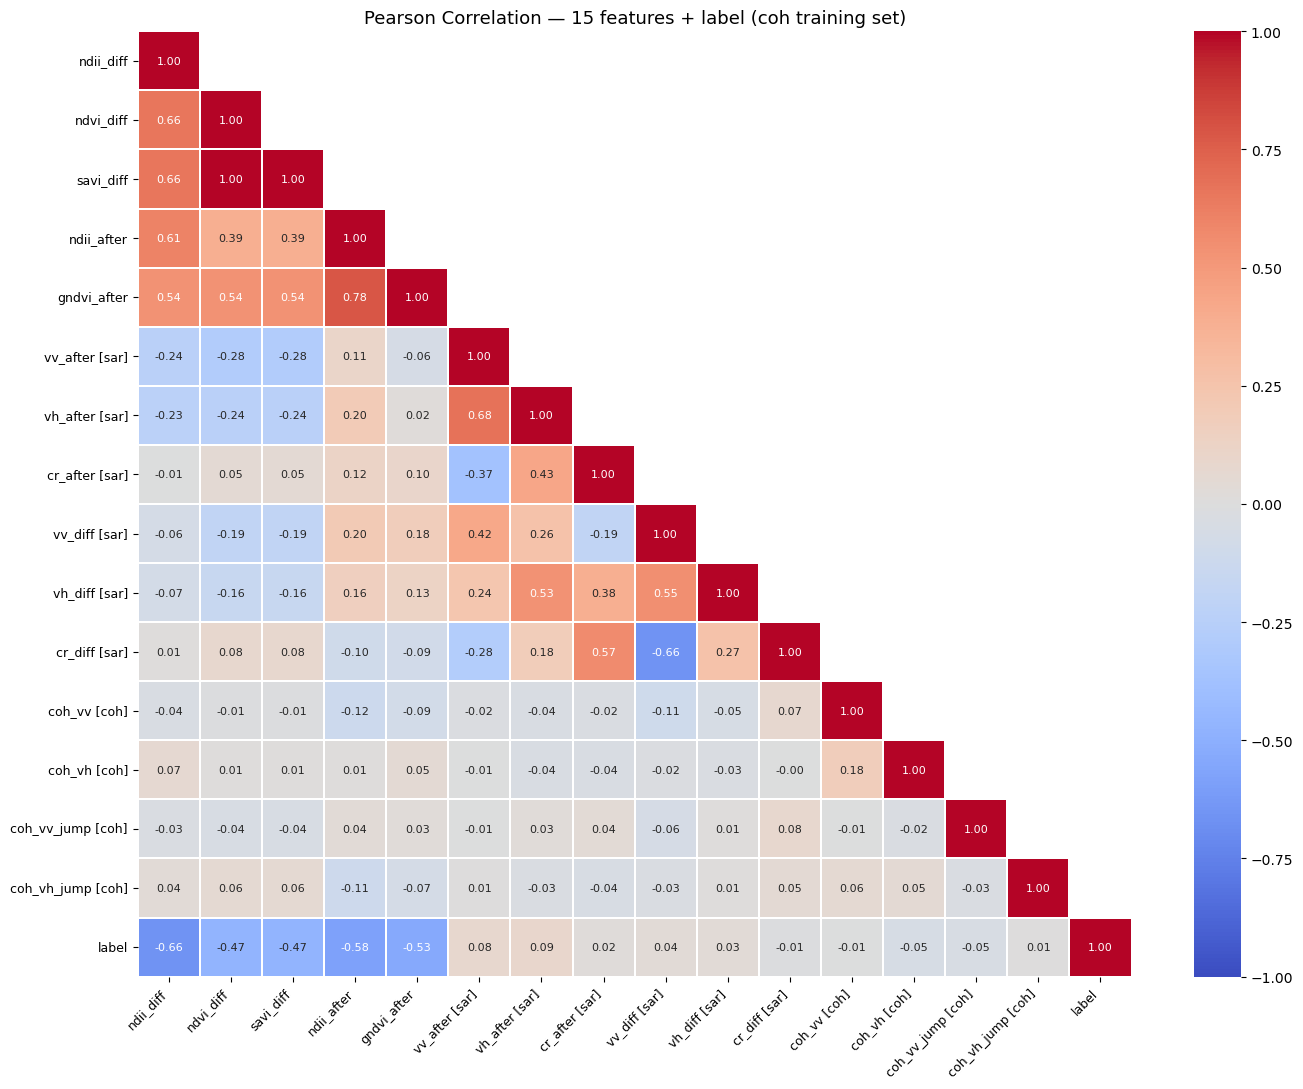

Saved: docs/images/feature_correlation_matrix.png

Highly correlated feature pairs (|r| > 0.85):
  savi_diff                      ↔  ndvi_diff                       r=1.000


In [16]:
import seaborn as sns

# Pearson correlation on the coherence training set (avoids test-set leakage).
corr_cols  = all_coh_features + ['label']
train_coh  = coh_df.loc[X_train_coh_all.index, corr_cols]
corr_matrix = train_coh.corr()

# Label the rows/columns with modality suffix for readability
label_map = {f: (f + ' [coh]' if f in COH_FEATURES else
                 f + ' [sar]' if f in SAR_FEATURES else f)
             for f in corr_cols}
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

# Lower-triangle mask (upper triangle is redundant)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    annot_kws={'size': 8}, linewidths=0.3, linecolor='white',
    ax=ax,
)
ax.set_title('Pearson Correlation — 15 features + label (coh training set)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'feature_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: docs/images/feature_correlation_matrix.png')

# Highlight high-correlation pairs (|r| > 0.85, excluding self and label)
print('\nHighly correlated feature pairs (|r| > 0.85):')
corr_vals = corr_matrix.drop(columns=['label'], errors='ignore').drop('label', errors='ignore')
mask_lt = np.tril(np.ones(corr_vals.shape, dtype=bool), k=-1)
corr_unstacked = corr_vals.where(mask_lt).stack()
high_corr = corr_unstacked[corr_unstacked.abs() > 0.85]
if high_corr.empty:
    print('  None — no severe redundancy among features.')
else:
    for (f1, f2), r in high_corr.items():
        print(f'  {f1:<30} ↔  {f2:<30}  r={r:.3f}')

---
## 6. Results Summary

In [33]:
cols = ['Model', 'Num_Features', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'TP', 'FP', 'FN']
results_s2_df  = pd.DataFrame(results_s2)
results_grd_df = pd.DataFrame(results_grd)
coh_results_df = pd.DataFrame(coh_results)

print('=== Config 1: S2-only (trained on ALL S2 events) ===')
print(results_s2_df[cols].sort_values('F1_Score', ascending=False).to_string(index=False))
print()
print('=== Configs 2-4: GRD group (63 events with S1 coverage) ===')
print('Note: test set differs from S2-only — F1 scores not directly comparable across groups')
print(results_grd_df[cols].sort_values('F1_Score', ascending=False).to_string(index=False))
print()
print('=== Coherence Group (coherence-eligible events only) ===')
print(coh_results_df[cols].sort_values('F1_Score', ascending=False).to_string(index=False))

=== Config 1: S2-only (trained on ALL S2 events) ===
       Model  Num_Features  Precision   Recall  F1_Score  ROC_AUC   TP  FP  FN
 S2-only SVM             5   0.934157 0.928292  0.928552    0.955 4193  76 528
S2-only LGBM             5   0.929358 0.924849  0.925110    0.969 4209 121 512
  S2-only RF             5   0.926419 0.921881  0.922153    0.967 4196 133 525

=== Configs 2-4: GRD group (63 events with S1 coverage) ===
Note: test set differs from S2-only — F1 scores not directly comparable across groups
            Model  Num_Features  Precision   Recall  F1_Score  ROC_AUC   TP   FP   FN
  S2+S1 Fusion RF            11   0.925306 0.920575  0.920854    0.962 4186  134  535
    Hybrid+SAR RF            10   0.922302 0.916301  0.916605    0.963 4140  124  581
S2+S1 Fusion LGBM            11   0.912989 0.908227  0.908550    0.961 4134  186  587
 S2+S1 Fusion SVM            11   0.913770 0.907396  0.907735    0.968 4095  154  626
   Hybrid+SAR SVM            10   0.912962 0.907159  0

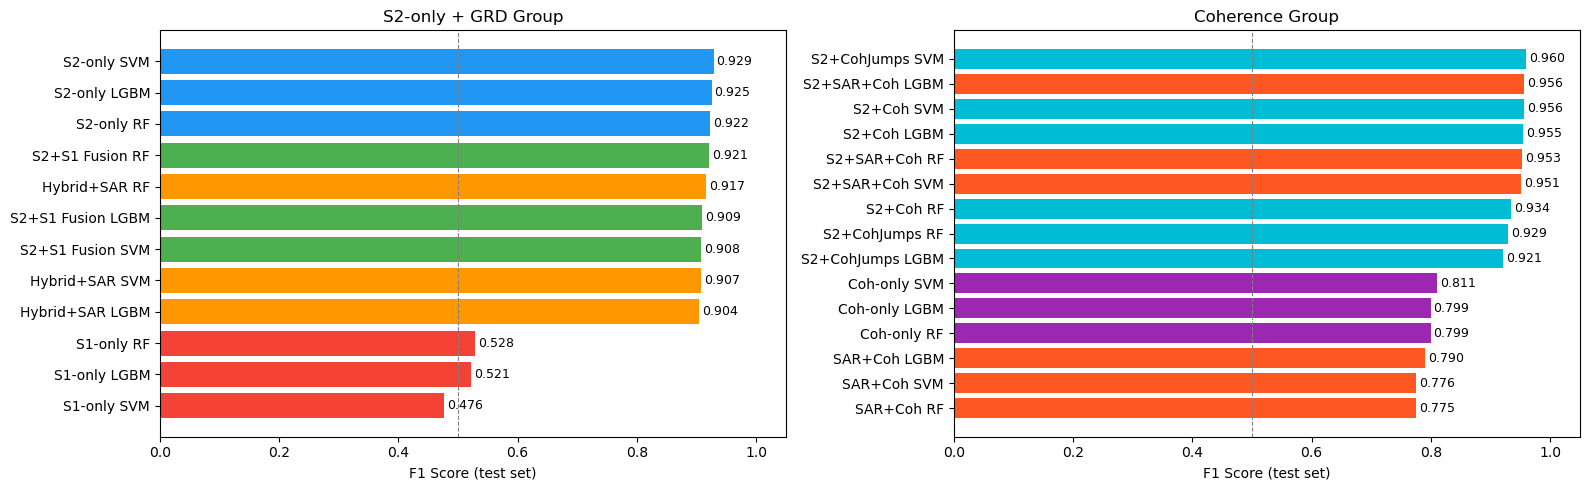

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def _bar_chart(ax, df, title):
    color_map = {
        'S2': '#2196F3', 'S1': '#F44336', 'Coh': '#9C27B0',
        'Fusion': '#4CAF50', 'Hybrid': '#FF9800', 'SAR': '#FF5722', 'Full': '#009688'
    }
    colors = []
    for m in df['Model']:
        if 'S2-only' in m:    colors.append('#2196F3')
        elif 'S1-only' in m:  colors.append('#F44336')
        elif 'Coh-only' in m: colors.append('#9C27B0')
        elif 'SAR+Coh' in m:  colors.append('#FF5722')
        elif 'S2+Coh' in m:   colors.append('#00BCD4')
        elif 'Full' in m or 'S2+SAR+Coh' in m: colors.append('#009688')
        elif 'Fusion' in m:   colors.append('#4CAF50')
        else:                  colors.append('#FF9800')
    bars = ax.barh(df['Model'], df['F1_Score'], color=colors)
    ax.set_xlabel('F1 Score (test set)')
    ax.set_title(title)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, df['F1_Score']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

_bar_chart(axes[0], pd.concat([results_s2_df, results_grd_df]).sort_values('F1_Score'), 'S2-only + GRD Group')
_bar_chart(axes[1], coh_results_df.sort_values('F1_Score'), 'Coherence Group')
plt.tight_layout()
plt.show()

---
## 7. Save Best Models

In [35]:
# ---------------------------------------------------------------------------
# Save all 12 deployable models: 4 configs × 3 model types (SVM, RF, LGBM)
#
# Configs saved:  1 (S2-only)  |  7 (S2+Coh)  |  9 (S2+CohJumps)  |  5 (Coh-only)
# GRD-based configs (S1-only, S2+S1, Hybrid+SAR, SAR+Coh, S2+SAR+Coh) are omitted:
# SAR GRD adds no consistent benefit over S2-only at real-scene application.
#
# Naming convention: {config}_{model_type}.joblib  (no "best" / "retrained" suffixes)
# Threshold: PR-curve optimum on each config's test set (scene calibration in nb09).
# ---------------------------------------------------------------------------

# Convenience: test sets per group, sliced to the right feature subsets
s2_X_test  = X_test_s2_all                                       # Config 1
s2c_X_test = X_test_coh_all[S2_LEAN_FEATURES + COH_FEATURES]     # Config 7
s2j_X_test = X_test_coh_all[S2_LEAN_FEATURES + COH_JUMP_FEATURES] # Config 9
co_X_test  = X_test_coh_all[COH_FEATURES]                        # Config 5

save_spec = [
    # (model_object,  feature_list,                            test_X,     test_y,     filename,                 alias)
    # --- Config 1: S2-only ---
    (model_s2_svm,   S2_LEAN_FEATURES,                        s2_X_test,  y_test_s2,  's2only_svm.joblib',        'S2-only SVM'),
    (model_s2_rf,    S2_LEAN_FEATURES,                        s2_X_test,  y_test_s2,  's2only_rf.joblib',         'S2-only RF'),
    (model_s2_lgbm,  S2_LEAN_FEATURES,                        s2_X_test,  y_test_s2,  's2only_lgbm.joblib',       'S2-only LGBM'),
    # --- Config 7: S2+Coh ---
    (model_s2c_svm,  S2_LEAN_FEATURES + COH_FEATURES,         s2c_X_test, y_test_coh, 's2coh_svm.joblib',         'S2+Coh SVM'),
    (model_s2c_rf,   S2_LEAN_FEATURES + COH_FEATURES,         s2c_X_test, y_test_coh, 's2coh_rf.joblib',          'S2+Coh RF'),
    (model_s2c_lgbm, S2_LEAN_FEATURES + COH_FEATURES,         s2c_X_test, y_test_coh, 's2coh_lgbm.joblib',        'S2+Coh LGBM'),
    # --- Config 9: S2+CohJumps (thesis main result) ---
    (model_s2j_svm,  S2_LEAN_FEATURES + COH_JUMP_FEATURES,    s2j_X_test, y_test_coh, 's2coh_jumps_svm.joblib',   'S2+CohJumps SVM'),
    (model_s2j_rf,   S2_LEAN_FEATURES + COH_JUMP_FEATURES,    s2j_X_test, y_test_coh, 's2coh_jumps_rf.joblib',    'S2+CohJumps RF'),
    (model_s2j_lgbm, S2_LEAN_FEATURES + COH_JUMP_FEATURES,    s2j_X_test, y_test_coh, 's2coh_jumps_lgbm.joblib',  'S2+CohJumps LGBM'),
    # --- Config 5: Coh-only ---
    (model_co_svm,   COH_FEATURES,                             co_X_test,  y_test_coh, 'coh_only_svm.joblib',      'Coh-only SVM'),
    (model_co_rf,    COH_FEATURES,                             co_X_test,  y_test_coh, 'coh_only_rf.joblib',       'Coh-only RF'),
    (model_co_lgbm,  COH_FEATURES,                             co_X_test,  y_test_coh, 'coh_only_lgbm.joblib',     'Coh-only LGBM'),
]

# Merge result tables for F1@0.5 lookup
all_results_df = pd.concat([results_s2_df, coh_results_df], ignore_index=True)

summary_rows = []
for model, features, test_X, test_y, filename, alias in save_spec:
    t, f1_opt = find_optimal_threshold(model, test_X, test_y)
    match = all_results_df.loc[all_results_df['Model'] == alias, 'F1_Score']
    f1_half = float(match.values[0]) if not match.empty else float('nan')
    joblib.dump({'model': model, 'features': features, 'threshold': t},
                os.path.join(MODELS_DIR, filename))
    summary_rows.append({
        'Model': alias, 'Artifact': filename,
        'F1@0.5': f1_half, 'Threshold': t, 'F1@opt': f1_opt,
        'Delta_F1': f1_opt - f1_half,
    })

summary_df = pd.DataFrame(summary_rows)
print('=== 12 Deployable Models Saved ===')
print('(Threshold from PR-curve on balanced test set; scene-level calibration done in nb09)\n')
print(summary_df[['Model', 'Artifact', 'F1@0.5', 'Threshold', 'F1@opt', 'Delta_F1']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nAll models saved to: {MODELS_DIR}')
print('\nNote: nb09 load_saved_model() calls must use the new filenames above.')

=== 12 Deployable Models Saved ===
(Threshold from PR-curve on balanced test set; scene-level calibration done in nb09)

           Model                Artifact  F1@0.5  Threshold  F1@opt  Delta_F1
     S2-only SVM       s2only_svm.joblib  0.9286     0.2855  0.9443    0.0158
      S2-only RF        s2only_rf.joblib  0.9222     0.3510  0.9301    0.0080
    S2-only LGBM      s2only_lgbm.joblib  0.9251     0.5042  0.9302    0.0051
      S2+Coh SVM        s2coh_svm.joblib  0.9556     0.6259  0.9579    0.0024
       S2+Coh RF         s2coh_rf.joblib  0.9343     0.6776  0.9363    0.0020
     S2+Coh LGBM       s2coh_lgbm.joblib  0.9550     0.6542  0.9598    0.0048
 S2+CohJumps SVM  s2coh_jumps_svm.joblib  0.9595     0.6516  0.9641    0.0045
  S2+CohJumps RF   s2coh_jumps_rf.joblib  0.9291     0.6257  0.9410    0.0119
S2+CohJumps LGBM s2coh_jumps_lgbm.joblib  0.9209     0.7739  0.9378    0.0169
    Coh-only SVM     coh_only_svm.joblib  0.8107     0.3590  0.8193    0.0086
     Coh-only RF     

---
## Summary

**What this notebook produced:**
- Test-set F1, precision, recall, ROC-AUC for 9 configs × 2 algorithms (18 models total)
- `models/s2only_retrained.joblib` — Config 1: S2-only (5 lean features)
- `models/fusion_best.joblib` — Config 3: best S2+S1 fusion model (11 features)
- `models/s2coh_best.joblib` — Config 7: S2 lean + all coherence (9 features)
- `models/fusion_coh_best.joblib` — Config 8: full fusion (15 features)
- `models/s2coh_jumps_best.joblib` — Config 9: S2 lean + coh jumps only (7 features, thesis main result)
- `models/coh_only_best.joblib` — Config 5: coherence-only baseline

**Key design decisions:**
- S2 features reduced from 20 → 5 (`ndii_diff`, `ndvi_diff`, `savi_diff`, `ndii_after`, `gndvi_after`) based on permutation importance
- Config 4 (PA2 hybrid) kept with its original 4 features for reproducibility comparison
- Config 9 separates the two jump coherence features from the absolute features to test whether mowing-induced coherence drop alone is sufficient

**Next step → notebook 09:** Apply the saved models to held-out scenes to populate the operational evaluation table.

# Features to best use accoring to claude:

Concrete recommended sets:


| Use case | Features (n) | Rationale |
|---|---|---|
|S2-only baseline | ndii_diff, ndvi_diff, savi_diff, ndii_after, gndvi_after (5) | Top permutation importance, low mutual correlation; drop the ~15 redundant/harmful features |
| With coherence (thesis main result) | above 5 + coh_vv_jump, coh_vh_jump (7 total) | The only two coherence features with positive permutation importance; coh_vv and coh_vh (absolute) are near-zero |
| With SAR forced in (for ablation completeness) | add cr_after only (8 total) | Only SAR feature with positive permutation importance; all others neutral or negative |


Drop with confidence: nir_diff, blue_after, swir_after, swir_diff, evi_diff, red_after, vh_after — all have negative permutation importance, meaning removing them should improve generalisation, not hurt it. coh_vv and coh_vh can also be dropped since only the jump features matter for mowing detection.

The Hybrid+SAR result (10 → 0.917 vs 26 → 0.910) already proves that fewer, better-chosen features outperform the full set on this data.

